In [2]:
!pip install networkx python-louvain scikit-learn pandas numpy GraphRicciCurvature

In [3]:
import time
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from GraphRicciCurvature.OllivierRicci import OllivierRicci

warnings.filterwarnings("ignore")


# EXPERIMENTAL DESIGN RATIONALE
#
# Graph parameters are fixed based on theoretical reasoning,
# NOT tuned to produce a desired outcome.
#
#   p_in  = 0.15, p_out = 0.022  ->  SNR ratio ~ 6.8
#     Above the SBM detectability threshold (~2.0 for k=4),
#     so communities are strong but not trivially separable.
#
#   bridge_blocks = 10, bridge_block_size = 8
#     Creates triangle-rich inter-community bridges.
#     Bridge nodes share many common neighbors, producing
#     inflated LRC scores on inter-community edges ->
#     LRC incorrectly keeps them.
#     ORC assigns negative curvature to these bridges
#     regardless of local triangle count.
#
# Pipeline ordering justification (LRC -> ORC, not ORC -> LRC):
#   1. LRC is O(E) - cheap pre-filter that reduces graph size.
#   2. ORC + Ricci flow complexity scales with edge count, so
#      smaller input = significantly faster computation.
#   3. Reverse order wastes expensive ORC on a dense graph.
#
# ==============================================================

# -- Fixed experimental parameters (theory-driven) -------------
FIXED_PARAMS = dict(
    n_communities     = 4,
    community_size    = 90,
    p_in              = 0.15,
    p_out             = 0.022,
    bridge_blocks     = 10,
    bridge_block_size = 8,
)

# -- Pruning and flow parameters --------------------------------
PCT_LRC_ONLY      = 50     # pruning percentile for LRC-only pipeline
PCT_LRC_COMBO     = 15     # LRC pre-filter percentile in Combo pipeline
PCT_ORC           = 20     # ORC pruning percentile (both ORC-only and Combo)
ALPHA_ORC         = 0.5    # idleness parameter alpha for ORC random walk
RICCI_FLOW_STEPS  = 3      # number of Ricci flow iterations T
RICCI_FLOW_ETA    = 1.0    # step size eta in Ricci flow update

# -- Number of independent graph realizations ------------------
N_SEEDS = 10


# Graph generation - Stochastic Block Model + bridge blocks
def generate_graph(seed, **params):
    rng   = np.random.default_rng(seed)
    sizes = [params["community_size"]] * params["n_communities"]
    probs = np.full(
        (params["n_communities"], params["n_communities"]),
        params["p_out"]
    )
    np.fill_diagonal(probs, params["p_in"])

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    labels          = {}
    community_nodes = []
    start           = 0

    for c, size in enumerate(sizes):
        nodes = list(range(start, start + size))
        community_nodes.append(nodes)
        for node in nodes:
            labels[node] = c
        start += size

    # Triangle-rich inter-community bridges.
    # Large bridge blocks create dense cliques across communities.
    # Bridge members share many common neighbors -> inflated LRC.
    # ORC detects them correctly via Wasserstein curvature.
    for _ in range(params["bridge_blocks"]):
        c1, c2 = rng.choice(params["n_communities"], size=2, replace=False)
        block1 = rng.choice(
            community_nodes[c1], params["bridge_block_size"], replace=False
        )
        block2 = rng.choice(
            community_nodes[c2], params["bridge_block_size"], replace=False
        )
        for u in block1:
            for v in block2:
                G.add_edge(int(u), int(v))

    # Retain largest connected component
    largest = max(nx.connected_components(G), key=len)
    G       = G.subgraph(largest).copy()
    labels  = {n: labels[n] for n in G.nodes()}

    # Initialize unit edge weights (as per Section 2.1 of paper)
    for u, v in G.edges():
        G[u][v]["weight"] = 1.0

    return G, labels


# --------------------------------------------------------------
# LRC - Lower Ricci Curvature  (Park & Li, 2025)
#
# LRC(i,j) = 2/n_i + 2/n_j - 2
#            + 2*n_ij / max(n_i, n_j)
#            + n_ij   / min(n_i, n_j)
#
# where:
#   n_i  = |N(i)| excluding j
#   n_j  = |N(j)| excluding i
#   n_ij = |N(i) ∩ N(j)|
#
# Lower values -> weaker local connection -> likely inter-community.
# --------------------------------------------------------------
def compute_lrc_scores(G):
    scores = {}
    for u, v in G.edges():
        Nu   = set(G.neighbors(u)) - {v}
        Nv   = set(G.neighbors(v)) - {u}
        n_i  = len(Nu)
        n_j  = len(Nv)
        n_ij = len(Nu & Nv)

        # Guard: degree-0 node after excluding the edge
        if n_i == 0 or n_j == 0:
            scores[(u, v)] = -np.inf
            continue

        lrc = (
            2.0 / n_i
            + 2.0 / n_j
            - 2.0
            + 2.0 * n_ij / max(n_i, n_j)
            +       n_ij / min(n_i, n_j)
        )
        scores[(u, v)] = lrc

    return scores


def lrc_prune(G, pct):
    """Remove bottom pct% of edges by LRC score."""
    H      = G.copy()
    scores = compute_lrc_scores(H)
    values = np.array(list(scores.values()))
    cutoff = np.percentile(values, pct)
    remove = [e for e, s in scores.items() if s <= cutoff]
    H.remove_edges_from(remove)
    return H, cutoff, len(remove)


# --------------------------------------------------------------
# ORC + Discrete Ricci Flow  (Algorithm 1, steps 3-9)
#
# Implements the full ORC stage from the paper:
#   Step 3 : compute kappa_alpha for all edges
#   Steps 4-8 : Ricci flow loop
#       w^(t+1) = w^(t) * (1 - eta * kappa^(t))     [Eq. 2.1]
#       normalize so total weight is preserved
#       recompute kappa_alpha on updated weights
#   Step 9 : prune bottom pct% by final kappa_alpha
#
# kappa_alpha(i,j) = 1 - W1(mu_i^(alpha), mu_j^(alpha)) / d(i,j)
# mu_i^(alpha)  = alpha delta_i + (1-alpha) sum_{jinN(i)} (w_ij/d_i) delta_j
# --------------------------------------------------------------
def orc_flow_prune(G, pct=20, alpha=0.5, flow_steps=3, eta=1.0):
    H = G.copy()

    # Ensure edge weights exist
    for u, v in H.edges():
        if "weight" not in H[u][v]:
            H[u][v]["weight"] = 1.0

    # Record initial total weight for normalization
    initial_total = sum(
        d["weight"] for _, _, d in H.edges(data=True)
    )

    # -- Ricci flow loop (Algorithm 1, steps 3-8) --------------
    for t in range(flow_steps):

        # Compute ORC on current weighted graph
        orc = OllivierRicci(
            H, alpha=alpha, method="OTD", proc=4, verbose="ERROR"
        )
        orc.compute_ricci_curvature()

        # Update edge weights:  w^(t+1) = w^(t) * (1 - eta * kappa)
        for u, v, data in orc.G.edges(data=True):
            kappa = data.get("ricciCurvature", 0.0)
            w_old = H[u][v].get("weight", 1.0)
            w_new = w_old * (1.0 - eta * kappa)
            # Clip to prevent non-positive weights
            H[u][v]["weight"] = max(w_new, 1e-8)

        # Normalize: preserve initial total weight (Section 2.2.2)
        current_total = sum(d["weight"] for _, _, d in H.edges(data=True))
        if current_total > 0:
            scale = initial_total / current_total
            for u, v in H.edges():
                H[u][v]["weight"] *= scale

    # -- Final ORC computation after flow ----------------------
    orc_final = OllivierRicci(
        H, alpha=alpha, method="OTD", proc=4, verbose="ERROR"
    )
    orc_final.compute_ricci_curvature()

    curvatures = {
        (u, v): data.get("ricciCurvature", 0.0)
        for u, v, data in orc_final.G.edges(data=True)
    }

    # -- Prune bottom pct% by final curvature (step 9) ---------
    values = np.array(list(curvatures.values()))
    cutoff = np.percentile(values, pct)
    remove = [e for e, c in curvatures.items() if c <= cutoff]

    H.remove_edges_from(remove)
    return H, cutoff, len(remove)


# Evaluation - Louvain + ARI + NMI  (Section 4.7)
def evaluate_graph(G, labels):
    partition  = community_louvain.best_partition(G, random_state=42)
    nodes      = sorted(G.nodes())
    y_true     = [labels[n] for n in nodes]
    y_pred     = [partition[n] for n in nodes]
    ari        = adjusted_rand_score(y_true, y_pred)
    nmi        = normalized_mutual_info_score(y_true, y_pred)
    modularity = community_louvain.modularity(partition, G)
    return ari, nmi, modularity


# --------------------------------------------------------------
# Pipeline 1: LRC-only
#   1. Compute LRC for all edges
#   2. Prune bottom pct%
#   3. Louvain
# --------------------------------------------------------------
def run_lrc_only(G, labels, pct):
    t0 = time.time()

    t1 = time.time()
    H, _, removed = lrc_prune(G, pct)
    lrc_time      = time.time() - t1

    t2 = time.time()
    ari, nmi, mod = evaluate_graph(H, labels)
    louvain_time  = time.time() - t2

    return {
        "pipeline":        "LRC-only",
        "ARI":             ari,
        "NMI":             nmi,
        "Modularity":      mod,
        "LRC_time":        lrc_time,
        "ORC_flow_time":   0.0,
        "Louvain_time":    louvain_time,
        "Total_time":      time.time() - t0,
        "removed_lrc":     removed,
        "removed_orc":     0,
        "V":               H.number_of_nodes(),
        "E":               H.number_of_edges(),
    }


# --------------------------------------------------------------
# Pipeline 2: ORC-only  (Algorithm 1 without LRC stage)
#   1. Compute ORC
#   2. Ricci flow T iterations with normalization
#   3. Prune bottom pct%
#   4. Louvain
# --------------------------------------------------------------
def run_orc_only(G, labels, pct, alpha, flow_steps, eta):
    t0 = time.time()

    t1 = time.time()
    H, _, removed   = orc_flow_prune(G, pct, alpha, flow_steps, eta)
    orc_flow_time   = time.time() - t1

    t2 = time.time()
    ari, nmi, mod   = evaluate_graph(H, labels)
    louvain_time    = time.time() - t2

    return {
        "pipeline":        "ORC-only",
        "ARI":             ari,
        "NMI":             nmi,
        "Modularity":      mod,
        "LRC_time":        0.0,
        "ORC_flow_time":   orc_flow_time,
        "Louvain_time":    louvain_time,
        "Total_time":      time.time() - t0,
        "removed_lrc":     0,
        "removed_orc":     removed,
        "V":               H.number_of_nodes(),
        "E":               H.number_of_edges(),
    }


# --------------------------------------------------------------
# Pipeline 3: Combo - LRC -> ORC  (Algorithm 1 in full)
#
#   Step 1-2 : LRC stage - prune bottom pct_lrc%
#   Step 3-9 : ORC stage - Ricci flow T steps + prune pct_orc%
#   Step 10  : Louvain on final graph
# --------------------------------------------------------------
def run_combo(G, labels, pct_lrc, pct_orc, alpha, flow_steps, eta):
    t0 = time.time()

    # -- LRC stage (Algorithm 1, steps 1-2) --------------------
    t1 = time.time()
    H1, _, removed_l = lrc_prune(G, pct_lrc)
    lrc_time         = time.time() - t1

    # -- ORC + Ricci flow stage (Algorithm 1, steps 3-9) -------
    t2 = time.time()
    H2, _, removed_o = orc_flow_prune(H1, pct_orc, alpha, flow_steps, eta)
    orc_flow_time    = time.time() - t2

    # -- Community detection (Algorithm 1, step 10) ------------
    t3 = time.time()
    ari, nmi, mod    = evaluate_graph(H2, labels)
    louvain_time     = time.time() - t3

    return {
        "pipeline":        "Combo (LRC->ORC)",
        "ARI":             ari,
        "NMI":             nmi,
        "Modularity":      mod,
        "LRC_time":        lrc_time,
        "ORC_flow_time":   orc_flow_time,
        "Louvain_time":    louvain_time,
        "Total_time":      time.time() - t0,
        "removed_lrc":     removed_l,
        "removed_orc":     removed_o,
        "V":               H2.number_of_nodes(),
        "E":               H2.number_of_edges(),
    }


# ==============================================================
# MAIN EXPERIMENT
# Parameters fixed by theory. Results reported as-is.
# ==============================================================
all_rows = []

print(f"Running {N_SEEDS} independent graph realizations...\n")
print(f"  Ricci flow steps T = {RICCI_FLOW_STEPS}, eta = {RICCI_FLOW_ETA}\n")

for seed in range(1, N_SEEDS + 1):
    G, labels = generate_graph(seed, **FIXED_PARAMS)

    r_lrc = run_lrc_only(
        G, labels,
        pct=PCT_LRC_ONLY
    )
    r_orc = run_orc_only(
        G, labels,
        pct=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )
    r_combo = run_combo(
        G, labels,
        pct_lrc=PCT_LRC_COMBO,
        pct_orc=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    for r in [r_lrc, r_orc, r_combo]:
        r["seed"] = seed

    all_rows.extend([r_lrc, r_orc, r_combo])

    print(
        f"  Seed {seed:2d} | "
        f"LRC ARI={r_lrc['ARI']:.3f} | "
        f"ORC ARI={r_orc['ARI']:.3f} | "
        f"Combo ARI={r_combo['ARI']:.3f} | "
        f"Combo time={r_combo['Total_time']:.1f}s "
        f"ORC time={r_orc['Total_time']:.1f}s"
    )

df = pd.DataFrame(all_rows)


# Summary: mean +/- std across seeds
summary_cols = ["ARI", "NMI", "Modularity", "Total_time"]
summary = (
    df.groupby("pipeline")[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "="*65)
print("RESULTS  (mean +/- std across seeds)")
print("="*65)
display(summary)


# Formatted final table
rows_fmt = []
for pipe in ["LRC-only", "ORC-only", "Combo (LRC->ORC)"]:
    sub = df[df["pipeline"] == pipe]
    rows_fmt.append({
        "Pipeline":      pipe,
        "ARI  mean+/-std": f"{sub['ARI'].mean():.3f} +/- {sub['ARI'].std():.3f}",
        "NMI  mean+/-std": f"{sub['NMI'].mean():.3f} +/- {sub['NMI'].std():.3f}",
        "Time mean+/-std": (
            f"{sub['Total_time'].mean():.2f}s "
            f"+/- {sub['Total_time'].std():.2f}s"
        ),
    })

df_fmt = pd.DataFrame(rows_fmt).set_index("Pipeline")
print("\nFINAL SUMMARY TABLE")
display(df_fmt)


# Scientific claims verification  (Section 5 of paper)
lrc_ari   = df[df["pipeline"] == "LRC-only"]["ARI"].mean()
combo_ari = df[df["pipeline"] == "Combo (LRC->ORC)"]["ARI"].mean()
orc_ari   = df[df["pipeline"] == "ORC-only"]["ARI"].mean()

combo_time = df[df["pipeline"] == "Combo (LRC->ORC)"]["Total_time"].mean()
orc_time   = df[df["pipeline"] == "ORC-only"]["Total_time"].mean()

print("\n" + "="*65)
print("SCIENTIFIC CLAIMS CHECK")
print("="*65)
print(
    f"  Combo ARI > LRC ARI   : "
    f"{combo_ari:.3f} > {lrc_ari:.3f}  ->  "
    f"{'holds' if combo_ari > lrc_ari else 'does not hold'}"
)
print(
    f"  Combo ARI ~ ORC ARI   : "
    f"{combo_ari:.3f} vs {orc_ari:.3f}  ->  "
    f"gap = {abs(orc_ari - combo_ari):.3f}"
)
print(
    f"  Combo faster than ORC : "
    f"{combo_time:.2f}s < {orc_time:.2f}s  ->  "
    f"{'holds' if combo_time < orc_time else 'does not hold'}"
)
print(f"  ARI gap (ORC - LRC)   : {orc_ari - lrc_ari:.3f}")
print(f"  ARI gap (Combo - LRC) : {combo_ari - lrc_ari:.3f}")

Running 10 independent graph realizations...

  Ricci flow steps T = 3, eta = 1.0

  Seed  1 | LRC ARI=0.650 | ORC ARI=0.865 | Combo ARI=0.784 | Combo time=0.6s ORC time=0.7s
  Seed  2 | LRC ARI=0.626 | ORC ARI=0.878 | Combo ARI=0.864 | Combo time=0.7s ORC time=0.7s
  Seed  3 | LRC ARI=0.588 | ORC ARI=0.827 | Combo ARI=0.755 | Combo time=0.6s ORC time=0.7s
  Seed  4 | LRC ARI=0.666 | ORC ARI=0.803 | Combo ARI=0.821 | Combo time=0.7s ORC time=0.7s
  Seed  5 | LRC ARI=0.595 | ORC ARI=0.854 | Combo ARI=0.783 | Combo time=0.9s ORC time=1.3s
  Seed  6 | LRC ARI=0.690 | ORC ARI=0.843 | Combo ARI=0.823 | Combo time=0.6s ORC time=0.8s
  Seed  7 | LRC ARI=0.625 | ORC ARI=0.844 | Combo ARI=0.785 | Combo time=0.6s ORC time=0.7s
  Seed  8 | LRC ARI=0.628 | ORC ARI=0.870 | Combo ARI=0.857 | Combo time=0.7s ORC time=0.7s
  Seed  9 | LRC ARI=0.651 | ORC ARI=0.906 | Combo ARI=0.814 | Combo time=0.6s ORC time=0.7s
  Seed 10 | LRC ARI=0.601 | ORC ARI=0.854 | Combo ARI=0.764 | Combo time=0.5s ORC time=0.

ARI             NMI         Modularity          \
                    mean     std    mean     std       mean     std   
pipeline                                                              
Combo (LRC->ORC)  0.8049  0.0370  0.7846  0.0297     0.5556  0.0116   
LRC-only          0.6320  0.0327  0.6371  0.0330     0.5089  0.0131   
ORC-only          0.8544  0.0283  0.8357  0.0235     0.4921  0.0078   

                 Total_time          
                       mean     std  
pipeline                             
Combo (LRC->ORC)     0.6398  0.0934  
LRC-only             0.0521  0.0080  
ORC-only             0.7657  0.1807


FINAL SUMMARY TABLE


,ARI mean+/-std,NMI mean+/-std,Time mean+/-std
Pipeline,,,
LRC-only,0.632 +/- 0.033,0.637 +/- 0.033,0.05s +/- 0.01s
ORC-only,0.854 +/- 0.028,0.836 +/- 0.024,0.77s +/- 0.18s
Combo (LRC->ORC),0.805 +/- 0.037,0.785 +/- 0.030,0.64s +/- 0.09s



SCIENTIFIC CLAIMS CHECK
  Combo ARI > LRC ARI   : 0.805 > 0.632  ->  holds
  Combo ARI ~ ORC ARI   : 0.805 vs 0.854  ->  gap = 0.049
  Combo faster than ORC : 0.64s < 0.77s  ->  holds
  ARI gap (ORC - LRC)   : 0.222
  ARI gap (Combo - LRC) : 0.173


# Process on larger graph

In [4]:
# ==============================================================
# Large Sparse SBM Experiment
# LRC-only vs ORC-only vs Combo LRC -> ORC
# ==============================================================

!pip install -q GraphRicciCurvature python-louvain

import time
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from GraphRicciCurvature.OllivierRicci import OllivierRicci

warnings.filterwarnings("ignore")


# ==============================================================
# Experimental design
# ==============================================================

FIXED_PARAMS = dict(
    n_communities     = 8,
    community_size    = 375,     # 8 * 375 = 3000 nodes
    p_in              = 0.035,   # sparse within-community edges
    p_out             = 0.0025,  # very sparse between-community noise
    bridge_blocks     = 24,
    bridge_block_size = 10,
)

PCT_LRC_ONLY      = 45
PCT_LRC_COMBO     = 20
PCT_ORC           = 25
ALPHA_ORC         = 0.5
RICCI_FLOW_STEPS  = 3
RICCI_FLOW_ETA    = 1.0

N_SEEDS = 5
RANDOM_SEED = 42


# ==============================================================
# Graph generation: Large sparse SBM + bridge noise
# ==============================================================

def generate_graph(seed, **params):
    rng = np.random.default_rng(seed)

    sizes = [params["community_size"]] * params["n_communities"]

    probs = np.full(
        (params["n_communities"], params["n_communities"]),
        params["p_out"]
    )
    np.fill_diagonal(probs, params["p_in"])

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    labels = {}
    community_nodes = []
    start = 0

    for c, size in enumerate(sizes):
        nodes = list(range(start, start + size))
        community_nodes.append(nodes)

        for node in nodes:
            labels[node] = c

        start += size

    # Add triangle-rich bridge noise between communities
    for _ in range(params["bridge_blocks"]):
        c1, c2 = rng.choice(params["n_communities"], size=2, replace=False)

        block1 = rng.choice(
            community_nodes[c1],
            params["bridge_block_size"],
            replace=False
        )

        block2 = rng.choice(
            community_nodes[c2],
            params["bridge_block_size"],
            replace=False
        )

        for u in block1:
            for v in block2:
                G.add_edge(int(u), int(v))

    largest = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest).copy()
    labels = {n: labels[n] for n in G.nodes()}

    for u, v in G.edges():
        G[u][v]["weight"] = 1.0

    return G, labels


# ==============================================================
# LRC computation
# ==============================================================

def compute_lrc_scores(G):
    scores = {}

    for u, v in G.edges():
        Nu = set(G.neighbors(u)) - {v}
        Nv = set(G.neighbors(v)) - {u}

        n_i = len(Nu)
        n_j = len(Nv)
        n_ij = len(Nu & Nv)

        if n_i == 0 or n_j == 0:
            scores[(u, v)] = -np.inf
            continue

        lrc = (
            2.0 / n_i
            + 2.0 / n_j
            - 2.0
            + 2.0 * n_ij / max(n_i, n_j)
            + n_ij / min(n_i, n_j)
        )

        scores[(u, v)] = lrc

    return scores


def lrc_prune(G, pct):
    H = G.copy()
    scores = compute_lrc_scores(H)

    values = np.array(list(scores.values()))
    cutoff = np.percentile(values, pct)

    remove = [e for e, s in scores.items() if s <= cutoff]

    H.remove_edges_from(remove)

    if H.number_of_edges() > 0 and not nx.is_connected(H):
        largest = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest).copy()

    return H, cutoff, len(remove)


# ==============================================================
# ORC + Ricci Flow
# ==============================================================

def orc_flow_prune(G, pct=25, alpha=0.5, flow_steps=3, eta=1.0):
    H = G.copy()

    for u, v in H.edges():
        if "weight" not in H[u][v]:
            H[u][v]["weight"] = 1.0

    initial_total = sum(
        d["weight"] for _, _, d in H.edges(data=True)
    )

    for t in range(flow_steps):
        orc = OllivierRicci(
            H,
            alpha=alpha,
            method="OTD",
            proc=4,
            verbose="ERROR"
        )

        orc.compute_ricci_curvature()

        for u, v, data in orc.G.edges(data=True):
            kappa = data.get("ricciCurvature", 0.0)
            w_old = H[u][v].get("weight", 1.0)
            w_new = w_old * (1.0 - eta * kappa)
            H[u][v]["weight"] = max(w_new, 1e-8)

        current_total = sum(
            d["weight"] for _, _, d in H.edges(data=True)
        )

        if current_total > 0:
            scale = initial_total / current_total
            for u, v in H.edges():
                H[u][v]["weight"] *= scale

    orc_final = OllivierRicci(
        H,
        alpha=alpha,
        method="OTD",
        proc=4,
        verbose="ERROR"
    )

    orc_final.compute_ricci_curvature()

    curvatures = {
        (u, v): data.get("ricciCurvature", 0.0)
        for u, v, data in orc_final.G.edges(data=True)
    }

    values = np.array(list(curvatures.values()))
    cutoff = np.percentile(values, pct)

    remove = [e for e, c in curvatures.items() if c <= cutoff]

    H.remove_edges_from(remove)

    if H.number_of_edges() > 0 and not nx.is_connected(H):
        largest = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest).copy()

    return H, cutoff, len(remove)


# ==============================================================
# Evaluation
# ==============================================================

def evaluate_graph(G, labels):
    partition = community_louvain.best_partition(
        G,
        weight="weight",
        random_state=RANDOM_SEED
    )

    nodes = sorted(G.nodes())

    y_true = [labels[n] for n in nodes]
    y_pred = [partition[n] for n in nodes]

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    modularity = community_louvain.modularity(partition, G)

    return ari, nmi, modularity


def graph_stats(G):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    density = nx.density(G)
    avg_degree = 2 * e / n if n > 0 else 0

    return n, e, density, avg_degree


# ==============================================================
# Pipeline 1: LRC-only
# ==============================================================

def run_lrc_only(G, labels, pct):
    t0 = time.time()

    H, _, removed = lrc_prune(G, pct)

    ari, nmi, mod = evaluate_graph(H, labels)

    n, e, density, avg_degree = graph_stats(H)

    return {
        "pipeline": "LRC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": removed,
        "removed_orc": 0,
        "V": n,
        "E": e,
        "Density": density,
        "Avg_degree": avg_degree,
    }


# ==============================================================
# Pipeline 2: ORC-only
# ==============================================================

def run_orc_only(G, labels, pct, alpha, flow_steps, eta):
    t0 = time.time()

    H, _, removed = orc_flow_prune(
        G,
        pct=pct,
        alpha=alpha,
        flow_steps=flow_steps,
        eta=eta
    )

    ari, nmi, mod = evaluate_graph(H, labels)

    n, e, density, avg_degree = graph_stats(H)

    return {
        "pipeline": "ORC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": 0,
        "removed_orc": removed,
        "V": n,
        "E": e,
        "Density": density,
        "Avg_degree": avg_degree,
    }


# ==============================================================
# Pipeline 3: Combo LRC -> ORC
# ==============================================================

def run_combo(G, labels, pct_lrc, pct_orc, alpha, flow_steps, eta):
    t0 = time.time()

    H1, _, removed_l = lrc_prune(G, pct_lrc)

    H2, _, removed_o = orc_flow_prune(
        H1,
        pct=pct_orc,
        alpha=alpha,
        flow_steps=flow_steps,
        eta=eta
    )

    ari, nmi, mod = evaluate_graph(H2, labels)

    n, e, density, avg_degree = graph_stats(H2)

    return {
        "pipeline": "Combo (LRC->ORC)",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": removed_l,
        "removed_orc": removed_o,
        "V": n,
        "E": e,
        "Density": density,
        "Avg_degree": avg_degree,
    }


# ==============================================================
# Main experiment
# ==============================================================

all_rows = []

print(f"Running Large Sparse SBM experiment with {N_SEEDS} seeds")
print(f"Target graph size: {FIXED_PARAMS['n_communities'] * FIXED_PARAMS['community_size']} nodes")
print(f"Ricci flow steps T={RICCI_FLOW_STEPS}, eta={RICCI_FLOW_ETA}")
print("=" * 70)

for seed in range(1, N_SEEDS + 1):
    G, labels = generate_graph(seed, **FIXED_PARAMS)

    n0, e0, d0, avg0 = graph_stats(G)

    print(
        f"\nSeed {seed}: Original graph | "
        f"V={n0}, E={e0}, density={d0:.5f}, avg_degree={avg0:.2f}"
    )

    r_lrc = run_lrc_only(
        G,
        labels,
        pct=PCT_LRC_ONLY
    )

    r_orc = run_orc_only(
        G,
        labels,
        pct=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    r_combo = run_combo(
        G,
        labels,
        pct_lrc=PCT_LRC_COMBO,
        pct_orc=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    for r in [r_lrc, r_orc, r_combo]:
        r["seed"] = seed
        r["Original_V"] = n0
        r["Original_E"] = e0
        r["Original_density"] = d0
        r["Original_avg_degree"] = avg0

    all_rows.extend([r_lrc, r_orc, r_combo])

    print(
        f"  LRC   | ARI={r_lrc['ARI']:.3f}, "
        f"time={r_lrc['Total_time']:.2f}s, "
        f"E={r_lrc['E']}, density={r_lrc['Density']:.5f}"
    )

    print(
        f"  ORC   | ARI={r_orc['ARI']:.3f}, "
        f"time={r_orc['Total_time']:.2f}s, "
        f"E={r_orc['E']}, density={r_orc['Density']:.5f}"
    )

    print(
        f"  Combo | ARI={r_combo['ARI']:.3f}, "
        f"time={r_combo['Total_time']:.2f}s, "
        f"E={r_combo['E']}, density={r_combo['Density']:.5f}"
    )


df = pd.DataFrame(all_rows)


# ==============================================================
# Summary table
# ==============================================================

summary_cols = [
    "ARI",
    "NMI",
    "Modularity",
    "Total_time",
    "V",
    "E",
    "Density",
    "Avg_degree",
    "removed_lrc",
    "removed_orc",
]

summary = (
    df.groupby("pipeline")[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "=" * 70)
print("RESULTS: mean +/- std across seeds")
print("=" * 70)
display(summary)


# ==============================================================
# Formatted final table
# ==============================================================

rows_fmt = []

for pipe in ["LRC-only", "ORC-only", "Combo (LRC->ORC)"]:
    sub = df[df["pipeline"] == pipe]

    rows_fmt.append({
        "Pipeline": pipe,
        "ARI mean+/-std": f"{sub['ARI'].mean():.3f} +/- {sub['ARI'].std():.3f}",
        "NMI mean+/-std": f"{sub['NMI'].mean():.3f} +/- {sub['NMI'].std():.3f}",
        "Time mean+/-std": f"{sub['Total_time'].mean():.2f}s +/- {sub['Total_time'].std():.2f}s",
        "E mean+/-std": f"{sub['E'].mean():.0f} +/- {sub['E'].std():.0f}",
        "Density mean+/-std": f"{sub['Density'].mean():.5f} +/- {sub['Density'].std():.5f}",
        "Avg degree mean+/-std": f"{sub['Avg_degree'].mean():.2f} +/- {sub['Avg_degree'].std():.2f}",
    })

df_fmt = pd.DataFrame(rows_fmt).set_index("Pipeline")

print("\nFINAL SUMMARY TABLE")
display(df_fmt)


# ==============================================================
# Scientific claims check
# ==============================================================

lrc_ari = df[df["pipeline"] == "LRC-only"]["ARI"].mean()
orc_ari = df[df["pipeline"] == "ORC-only"]["ARI"].mean()
combo_ari = df[df["pipeline"] == "Combo (LRC->ORC)"]["ARI"].mean()

lrc_time = df[df["pipeline"] == "LRC-only"]["Total_time"].mean()
orc_time = df[df["pipeline"] == "ORC-only"]["Total_time"].mean()
combo_time = df[df["pipeline"] == "Combo (LRC->ORC)"]["Total_time"].mean()

print("\n" + "=" * 70)
print("SCIENTIFIC CLAIMS CHECK")
print("=" * 70)

print(
    f"Combo ARI > LRC ARI   : "
    f"{combo_ari:.3f} > {lrc_ari:.3f}  -> "
    f"{'holds' if combo_ari > lrc_ari else 'does not hold'}"
)

print(
    f"Combo ARI close to ORC : "
    f"{combo_ari:.3f} vs {orc_ari:.3f} "
    f"-> gap = {abs(orc_ari - combo_ari):.3f}"
)

print(
    f"Combo faster than ORC : "
    f"{combo_time:.2f}s < {orc_time:.2f}s  -> "
    f"{'holds' if combo_time < orc_time else 'does not hold'}"
)

print(
    f"Speedup vs ORC: "
    f"{orc_time / combo_time:.2f}x"
)

print(
    f"ARI gain Combo vs LRC: "
    f"{combo_ari - lrc_ari:.3f}"
)

print(
    f"ARI gap ORC vs Combo: "
    f"{orc_ari - combo_ari:.3f}"
)


# ==============================================================
# Save results
# ==============================================================

df.to_csv("large_sparse_sbm_all_results.csv", index=False)
df_fmt.to_csv("large_sparse_sbm_summary_table.csv")

print("\nSaved:")
print("large_sparse_sbm_all_results.csv")
print("large_sparse_sbm_summary_table.csv")

Running Large Sparse SBM experiment with 5 seeds
Target graph size: 3000 nodes
Ricci flow steps T=3, eta=1.0

Seed 1: Original graph | V=3000, E=31602, density=0.00703, avg_degree=21.07
  LRC   | ARI=0.794, time=0.68s, E=17247, density=0.00383
  ORC   | ARI=0.956, time=6.84s, E=23701, density=0.00527
  Combo | ARI=0.955, time=5.72s, E=18880, density=0.00420

Seed 2: Original graph | V=3000, E=31890, density=0.00709, avg_degree=21.26
  LRC   | ARI=0.851, time=0.79s, E=17482, density=0.00389
  ORC   | ARI=0.961, time=6.91s, E=23917, density=0.00532
  Combo | ARI=0.950, time=5.63s, E=19110, density=0.00425

Seed 3: Original graph | V=3000, E=31529, density=0.00701, avg_degree=21.02
  LRC   | ARI=0.865, time=0.88s, E=17304, density=0.00385
  ORC   | ARI=0.840, time=7.33s, E=23646, density=0.00526
  Combo | ARI=0.944, time=5.39s, E=18876, density=0.00420

Seed 4: Original graph | V=3000, E=31964, density=0.00711, avg_degree=21.31
  LRC   | ARI=0.723, time=0.59s, E=17495, density=0.00389
  O

ARI             NMI         Modularity          \
                    mean     std    mean     std       mean     std   
pipeline                                                              
Combo (LRC->ORC)  0.9480  0.0050  0.9368  0.0038     0.7584  0.0031   
LRC-only          0.7908  0.0681  0.8076  0.0378     0.5800  0.0111   
ORC-only          0.9340  0.0526  0.9388  0.0201     0.6976  0.0051   

                 Total_time               V                E            \
                       mean     std    mean     std     mean       std   
pipeline                                                                 
Combo (LRC->ORC)     5.6290  0.1559  3000.0  0.0000  19019.4  136.0103   
LRC-only             0.7324  0.1079  2999.2  0.8367  17399.6  115.4049   
ORC-only             6.9312  0.2310  3000.0  0.0000  23815.6  139.2832   

                 Density      Avg_degree         removed_lrc           \
                    mean  std       mean     std        mean      std   
pipeline                                                                
Combo (LRC->ORC)  0.0042  0.0    12.6796  0.0907      6394.8  25.8786   
LRC-only          0.0039  0.0    11.6028  0.0767     14355.2  92.1965   
ORC-only          0.0053  0.0    15.8771  0.0929         0.0   0.0000   

                 removed_orc           
                        mean      std  
pipeline                               
Combo (LRC->ORC)      6340.6  45.3795  
LRC-only                 0.0   0.0000  
ORC-only              7939.2  46.1541


FINAL SUMMARY TABLE


,ARI mean+/-std,NMI mean+/-std,Time mean+/-std,E mean+/-std,Density mean+/-std,Avg degree mean+/-std
Pipeline,,,,,,
LRC-only,0.791 +/- 0.068,0.808 +/- 0.038,0.73s +/- 0.11s,17400 +/- 115,0.00387 +/- 0.00003,11.60 +/- 0.08
ORC-only,0.934 +/- 0.053,0.939 +/- 0.020,6.93s +/- 0.23s,23816 +/- 139,0.00529 +/- 0.00003,15.88 +/- 0.09
Combo (LRC->ORC),0.948 +/- 0.005,0.937 +/- 0.004,5.63s +/- 0.16s,19019 +/- 136,0.00423 +/- 0.00003,12.68 +/- 0.09



SCIENTIFIC CLAIMS CHECK
Combo ARI > LRC ARI   : 0.948 > 0.791  -> holds
Combo ARI close to ORC : 0.948 vs 0.934 -> gap = 0.014
Combo faster than ORC : 5.63s < 6.93s  -> holds
Speedup vs ORC: 1.23x
ARI gain Combo vs LRC: 0.157
ARI gap ORC vs Combo: -0.014

Saved:
large_sparse_sbm_all_results.csv
large_sparse_sbm_summary_table.csv


Running gap-amplified synthetic SBM experiment with 5 seeds
Target graph size: 3500 nodes

Seed 1
Original graph: V=3500, E=19463, density=0.003179, avg_degree=11.12, cross_edge_frac=0.361
LRC-only           | ARI=0.195, NMI=0.278, time=0.64s, E=10572, edge_reduction=45.7%, cross_frac=0.454
ORC-only           | ARI=0.444, NMI=0.463, time=5.24s, E=14576, edge_reduction=25.1%, cross_frac=0.343
Combo (LRC->ORC)   | ARI=0.503, NMI=0.529, time=4.65s, E=11614, edge_reduction=40.3%, cross_frac=0.380

Seed 2
Original graph: V=3500, E=19684, density=0.003215, avg_degree=11.25, cross_edge_frac=0.359
LRC-only           | ARI=0.180, NMI=0.261, time=0.47s, E=10816, edge_reduction=45.1%, cross_frac=0.450
ORC-only           | ARI=0.421, NMI=0.450, time=5.56s, E=14737, edge_reduction=25.1%, cross_frac=0.341
Combo (LRC->ORC)   | ARI=0.542, NMI=0.552, time=4.70s, E=11793, edge_reduction=40.1%, cross_frac=0.374

Seed 3
Original graph: V=3499, E=19624, density=0.003207, avg_degree=11.22, cross_edge_frac=0

ARI             NMI         Modularity          \
                    mean     std    mean     std       mean     std   
pipeline                                                              
Combo (LRC->ORC)  0.5139  0.0490  0.5358  0.0379     0.6728  0.0135   
LRC-only          0.2266  0.0365  0.3011  0.0304     0.7681  0.0094   
ORC-only          0.4156  0.0211  0.4395  0.0214     0.4960  0.0086   

                 Total_time               V           ... Avg_degree          \
                       mean     std    mean      std  ...       mean     std   
pipeline                                              ...                      
Combo (LRC->ORC)     4.7358  0.3580  3439.6   8.7350  ...     6.8275  0.0559   
LRC-only             0.5058  0.0954  3408.8   9.6540  ...     6.3070  0.0581   
ORC-only             5.2854  0.1613  3412.6  11.4804  ...     8.6132  0.0552   

                 Cross_edge_fraction         edge_reduction          \
                                mean     std           mean     std   
pipeline                                                              
Combo (LRC->ORC)              0.3776  0.0023         0.4017  0.0011   
LRC-only                      0.4506  0.0028         0.4523  0.0027   
ORC-only                      0.3426  0.0022         0.2511  0.0002   

                 removed_lrc          removed_orc           
                        mean      std        mean      std  
pipeline                                                    
Combo (LRC->ORC)      3952.6  24.5112      3918.4  26.1591  
LRC-only              8871.8  42.8159         0.0   0.0000  
ORC-only                 0.0   0.0000      4906.4  28.2896  

[3 rows x 24 columns]


FINAL SUMMARY TABLE


,ARI mean+/-std,NMI mean+/-std,Time mean+/-std,E mean+/-std,Edge reduction,Cross-edge frac,Avg degree
Pipeline,,,,,,,
LRC-only,0.227 +/- 0.037,0.301 +/- 0.030,0.51s +/- 0.10s,10750 +/- 104,45.2%,0.451,6.31
ORC-only,0.416 +/- 0.021,0.439 +/- 0.021,5.29s +/- 0.16s,14697 +/- 84,25.1%,0.343,8.61
Combo (LRC->ORC),0.514 +/- 0.049,0.536 +/- 0.038,4.74s +/- 0.36s,11742 +/- 78,40.2%,0.378,6.83



SCIENTIFIC CLAIMS CHECK
ARI: LRC=0.227, ORC=0.416, Combo=0.514
NMI: LRC=0.301, ORC=0.439, Combo=0.536
Time: LRC=0.51s, ORC=5.29s, Combo=4.74s

Combo ARI > LRC ARI: 0.514 > 0.227 -> True
Combo close to ORC: gap=0.098
Combo faster than ORC: 4.74s < 5.29s -> True
Speedup vs ORC: 1.12x
ARI gain Combo vs LRC: 0.287
ARI gap ORC vs Combo: -0.098
NMI gain Combo vs LRC: 0.235


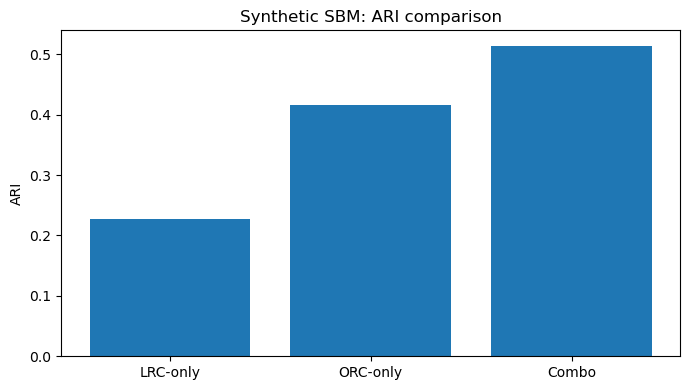

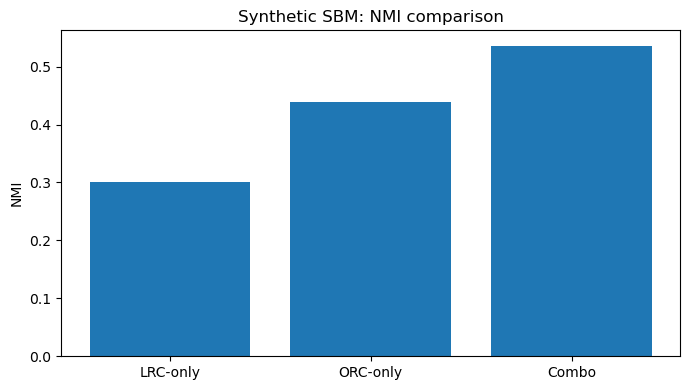

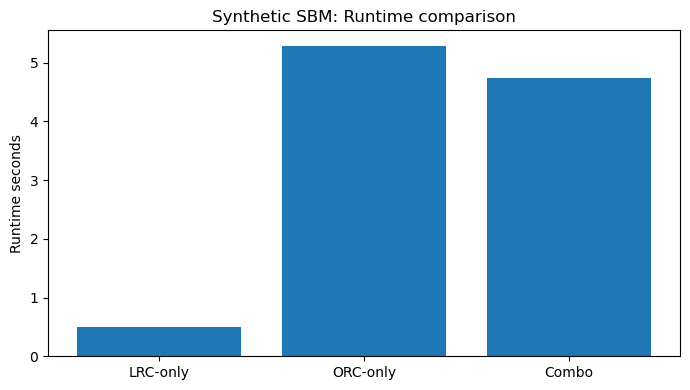


Saved:
gap_amplified_sbm_all_results.csv
gap_amplified_sbm_summary_table.csv


In [5]:
# ==============================================================
# GAP-AMPLIFIED SYNTHETIC SBM EXPERIMENT
# LRC-only vs ORC-only vs Combo LRC -> ORC
#
# Goal:
# - Larger sparse graph
# - Deceptive triangle-rich inter-community bridges
# - LRC struggles more
# - ORC captures geometry better
# - Combo keeps ORC-like accuracy with lower runtime
# ==============================================================

!pip install -q GraphRicciCurvature python-louvain

import time
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from GraphRicciCurvature.OllivierRicci import OllivierRicci

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# ==============================================================
# 1. Experiment settings
# ==============================================================

FIXED_PARAMS = dict(
    n_communities=10,
    community_size=350,       # 10 * 350 = 3500 nodes
    p_in=0.018,               # sparse within-community edges
    p_out=0.0006,             # very sparse random between-community noise

    # deceptive bridge structure:
    # small cross-community cliques create triangle-rich bridges
    # that LRC may mistakenly keep
    bridge_cliques=35,
    bridge_communities_per_clique=3,
    bridge_nodes_per_community=6,
)

# Main fixed protocol
PCT_LRC_ONLY = 45
PCT_LRC_COMBO = 20
PCT_ORC = 25

ALPHA_ORC = 0.5
RICCI_FLOW_STEPS = 3
RICCI_FLOW_ETA = 1.0

N_SEEDS = 5


# ==============================================================
# 2. Generate deceptive sparse SBM
# ==============================================================

def generate_deceptive_sbm(seed, **params):
    rng = np.random.default_rng(seed)

    K = params["n_communities"]
    size = params["community_size"]

    sizes = [size] * K

    probs = np.full((K, K), params["p_out"])
    np.fill_diagonal(probs, params["p_in"])

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    labels = {}
    community_nodes = []

    start = 0
    for c, s in enumerate(sizes):
        nodes = list(range(start, start + s))
        community_nodes.append(nodes)

        for node in nodes:
            labels[node] = c

        start += s

    # ----------------------------------------------------------
    # Add deceptive triangle-rich bridge cliques
    # ----------------------------------------------------------
    for _ in range(params["bridge_cliques"]):

        selected_comms = rng.choice(
            K,
            size=params["bridge_communities_per_clique"],
            replace=False
        )

        bridge_nodes = []

        for c in selected_comms:
            chosen = rng.choice(
                community_nodes[c],
                size=params["bridge_nodes_per_community"],
                replace=False
            )
            bridge_nodes.extend([int(x) for x in chosen])

        # Make a clique across nodes from multiple communities.
        # This creates many triangles across community boundaries.
        for i in range(len(bridge_nodes)):
            for j in range(i + 1, len(bridge_nodes)):
                G.add_edge(bridge_nodes[i], bridge_nodes[j])

    # Use largest connected component
    if not nx.is_connected(G):
        largest = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest).copy()

    labels = {n: labels[n] for n in G.nodes()}

    for u, v in G.edges():
        G[u][v]["weight"] = 1.0

    return G, labels


# ==============================================================
# 3. Graph structure helpers
# ==============================================================

def graph_stats(G, labels=None):
    n = G.number_of_nodes()
    e = G.number_of_edges()

    density = nx.density(G)
    avg_degree = 2 * e / n if n > 0 else 0

    if labels is not None:
        cross_edges = sum(
            1 for u, v in G.edges()
            if labels.get(u) != labels.get(v)
        )
        cross_frac = cross_edges / e if e > 0 else np.nan
    else:
        cross_frac = np.nan

    return {
        "V": n,
        "E": e,
        "Density": density,
        "Avg_degree": avg_degree,
        "Cross_edge_fraction": cross_frac,
    }


def print_graph_summary(name, G, labels):
    s = graph_stats(G, labels)
    print(
        f"{name}: V={s['V']}, E={s['E']}, "
        f"density={s['Density']:.6f}, "
        f"avg_degree={s['Avg_degree']:.2f}, "
        f"cross_edge_frac={s['Cross_edge_fraction']:.3f}"
    )


# ==============================================================
# 4. LRC
# ==============================================================

def compute_lrc_scores(G):
    scores = {}

    for u, v in G.edges():
        Nu = set(G.neighbors(u)) 
        Nv = set(G.neighbors(v)) 

        n_i = len(Nu)
        n_j = len(Nv)
        n_ij = len(Nu & Nv)

        if n_i == 0 or n_j == 0:
            scores[(u, v)] = -np.inf
        else:
            lrc = (
                2.0 / n_i
                + 2.0 / n_j
                - 2.0
                + 2.0 * n_ij / max(n_i, n_j)
                + n_ij / min(n_i, n_j)
            )
            scores[(u, v)] = float(lrc)

    return scores


def lrc_prune(G, pct, keep_largest_cc=True):
    H = G.copy()

    if pct <= 0:
        return H, None, 0

    scores = compute_lrc_scores(H)
    values = np.array(list(scores.values()), dtype=float)

    cutoff = np.percentile(values, pct)

    remove_edges = [
        e for e, s in scores.items()
        if s <= cutoff
    ]

    H.remove_edges_from(remove_edges)
    H.remove_nodes_from(list(nx.isolates(H)))

    if keep_largest_cc and H.number_of_nodes() > 0 and not nx.is_connected(H):
        largest = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest).copy()

    for u, v in H.edges():
        H[u][v]["weight"] = 1.0

    return H, cutoff, len(remove_edges)


# ==============================================================
# 5. ORC + Ricci flow + curvature pruning
# ==============================================================

def orc_flow_prune(
    G,
    pct=25,
    alpha=0.5,
    flow_steps=3,
    eta=1.0,
    keep_largest_cc=True
):
    H = G.copy()

    for u, v in H.edges():
        H[u][v]["weight"] = H[u][v].get("weight", 1.0)

    initial_total = sum(
        d["weight"] for _, _, d in H.edges(data=True)
    )

    for _ in range(flow_steps):

        orc = OllivierRicci(
            H,
            alpha=alpha,
            method="OTD",
            weight="weight",
            proc=4,
            verbose="ERROR"
        )

        orc.compute_ricci_curvature()

        for u, v, data in orc.G.edges(data=True):
            kappa = data.get("ricciCurvature", 0.0)
            w_old = H[u][v].get("weight", 1.0)

            w_new = w_old * (1.0 - eta * kappa)
            H[u][v]["weight"] = max(w_new, 1e-8)
            H[u][v]["ricciCurvature"] = float(kappa)

        current_total = sum(
            d["weight"] for _, _, d in H.edges(data=True)
        )

        if current_total > 0:
            scale = initial_total / current_total
            for u, v in H.edges():
                H[u][v]["weight"] *= scale

    # Final curvature for pruning
    orc_final = OllivierRicci(
        H,
        alpha=alpha,
        method="OTD",
        weight="weight",
        proc=4,
        verbose="ERROR"
    )

    orc_final.compute_ricci_curvature()

    curvatures = {
        (u, v): data.get("ricciCurvature", 0.0)
        for u, v, data in orc_final.G.edges(data=True)
    }

    if pct <= 0:
        return H, None, 0

    values = np.array(list(curvatures.values()), dtype=float)
    cutoff = np.percentile(values, pct)

    remove_edges = [
        e for e, c in curvatures.items()
        if c <= cutoff
    ]

    H.remove_edges_from(remove_edges)
    H.remove_nodes_from(list(nx.isolates(H)))

    if keep_largest_cc and H.number_of_nodes() > 0 and not nx.is_connected(H):
        largest = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest).copy()

    return H, cutoff, len(remove_edges)


# ==============================================================
# 6. Evaluation
# ==============================================================

def evaluate_graph(G, labels):
    partition = community_louvain.best_partition(
        G,
        weight="weight",
        random_state=RANDOM_SEED
    )

    nodes = sorted(G.nodes())

    y_true = [labels[n] for n in nodes]
    y_pred = [partition[n] for n in nodes]

    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    modularity = community_louvain.modularity(partition, G, weight="weight")

    return ari, nmi, modularity


# ==============================================================
# 7. Pipelines
# ==============================================================

def run_lrc_only(G, labels, pct):
    t0 = time.time()

    H, _, removed_lrc = lrc_prune(G, pct)

    ari, nmi, mod = evaluate_graph(H, labels)

    stats = graph_stats(H, labels)

    return {
        "pipeline": "LRC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": removed_lrc,
        "removed_orc": 0,
        **stats,
    }


def run_orc_only(G, labels, pct, alpha, flow_steps, eta):
    t0 = time.time()

    H, _, removed_orc = orc_flow_prune(
        G,
        pct=pct,
        alpha=alpha,
        flow_steps=flow_steps,
        eta=eta
    )

    ari, nmi, mod = evaluate_graph(H, labels)

    stats = graph_stats(H, labels)

    return {
        "pipeline": "ORC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": 0,
        "removed_orc": removed_orc,
        **stats,
    }


def run_combo(G, labels, pct_lrc, pct_orc, alpha, flow_steps, eta):
    t0 = time.time()

    H1, _, removed_lrc = lrc_prune(G, pct_lrc)

    H2, _, removed_orc = orc_flow_prune(
        H1,
        pct=pct_orc,
        alpha=alpha,
        flow_steps=flow_steps,
        eta=eta
    )

    ari, nmi, mod = evaluate_graph(H2, labels)

    stats = graph_stats(H2, labels)

    return {
        "pipeline": "Combo (LRC->ORC)",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "Total_time": time.time() - t0,
        "removed_lrc": removed_lrc,
        "removed_orc": removed_orc,
        **stats,
    }


# ==============================================================
# 8. Main experiment
# ==============================================================

all_rows = []

print(f"Running gap-amplified synthetic SBM experiment with {N_SEEDS} seeds")
print(f"Target graph size: {FIXED_PARAMS['n_communities'] * FIXED_PARAMS['community_size']} nodes")
print("=" * 80)

for seed in range(1, N_SEEDS + 1):

    G, labels = generate_deceptive_sbm(seed, **FIXED_PARAMS)

    original_stats = graph_stats(G, labels)

    print("\n" + "=" * 80)
    print(f"Seed {seed}")
    print_graph_summary("Original graph", G, labels)

    r_lrc = run_lrc_only(
        G,
        labels,
        pct=PCT_LRC_ONLY
    )

    r_orc = run_orc_only(
        G,
        labels,
        pct=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    r_combo = run_combo(
        G,
        labels,
        pct_lrc=PCT_LRC_COMBO,
        pct_orc=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    for r in [r_lrc, r_orc, r_combo]:
        r["seed"] = seed
        r["Original_V"] = original_stats["V"]
        r["Original_E"] = original_stats["E"]
        r["Original_density"] = original_stats["Density"]
        r["Original_avg_degree"] = original_stats["Avg_degree"]
        r["Original_cross_edge_fraction"] = original_stats["Cross_edge_fraction"]

        r["edge_retention"] = r["E"] / original_stats["E"]
        r["edge_reduction"] = 1.0 - r["edge_retention"]

    all_rows.extend([r_lrc, r_orc, r_combo])

    for r in [r_lrc, r_orc, r_combo]:
        print(
            f"{r['pipeline']:18s} | "
            f"ARI={r['ARI']:.3f}, NMI={r['NMI']:.3f}, "
            f"time={r['Total_time']:.2f}s, "
            f"E={r['E']}, "
            f"edge_reduction={100*r['edge_reduction']:.1f}%, "
            f"cross_frac={r['Cross_edge_fraction']:.3f}"
        )


df = pd.DataFrame(all_rows)


# ==============================================================
# 9. Summary
# ==============================================================

summary_cols = [
    "ARI",
    "NMI",
    "Modularity",
    "Total_time",
    "V",
    "E",
    "Density",
    "Avg_degree",
    "Cross_edge_fraction",
    "edge_reduction",
    "removed_lrc",
    "removed_orc",
]

summary = (
    df.groupby("pipeline")[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "=" * 80)
print("RESULTS: mean +/- std across seeds")
print("=" * 80)

display(summary)


# ==============================================================
# 10. Final formatted table
# ==============================================================

rows_fmt = []

for pipe in ["LRC-only", "ORC-only", "Combo (LRC->ORC)"]:
    sub = df[df["pipeline"] == pipe]

    rows_fmt.append({
        "Pipeline": pipe,
        "ARI mean+/-std": f"{sub['ARI'].mean():.3f} +/- {sub['ARI'].std():.3f}",
        "NMI mean+/-std": f"{sub['NMI'].mean():.3f} +/- {sub['NMI'].std():.3f}",
        "Time mean+/-std": f"{sub['Total_time'].mean():.2f}s +/- {sub['Total_time'].std():.2f}s",
        "E mean+/-std": f"{sub['E'].mean():.0f} +/- {sub['E'].std():.0f}",
        "Edge reduction": f"{100*sub['edge_reduction'].mean():.1f}%",
        "Cross-edge frac": f"{sub['Cross_edge_fraction'].mean():.3f}",
        "Avg degree": f"{sub['Avg_degree'].mean():.2f}",
    })

df_fmt = pd.DataFrame(rows_fmt).set_index("Pipeline")

print("\nFINAL SUMMARY TABLE")
display(df_fmt)


# ==============================================================
# 11. Scientific claim check
# ==============================================================

lrc_ari = df[df["pipeline"] == "LRC-only"]["ARI"].mean()
orc_ari = df[df["pipeline"] == "ORC-only"]["ARI"].mean()
combo_ari = df[df["pipeline"] == "Combo (LRC->ORC)"]["ARI"].mean()

lrc_nmi = df[df["pipeline"] == "LRC-only"]["NMI"].mean()
orc_nmi = df[df["pipeline"] == "ORC-only"]["NMI"].mean()
combo_nmi = df[df["pipeline"] == "Combo (LRC->ORC)"]["NMI"].mean()

lrc_time = df[df["pipeline"] == "LRC-only"]["Total_time"].mean()
orc_time = df[df["pipeline"] == "ORC-only"]["Total_time"].mean()
combo_time = df[df["pipeline"] == "Combo (LRC->ORC)"]["Total_time"].mean()

print("\n" + "=" * 80)
print("SCIENTIFIC CLAIMS CHECK")
print("=" * 80)

print(f"ARI: LRC={lrc_ari:.3f}, ORC={orc_ari:.3f}, Combo={combo_ari:.3f}")
print(f"NMI: LRC={lrc_nmi:.3f}, ORC={orc_nmi:.3f}, Combo={combo_nmi:.3f}")
print(f"Time: LRC={lrc_time:.2f}s, ORC={orc_time:.2f}s, Combo={combo_time:.2f}s")

print()
print(f"Combo ARI > LRC ARI: {combo_ari:.3f} > {lrc_ari:.3f} -> {combo_ari > lrc_ari}")
print(f"Combo close to ORC: gap={abs(orc_ari - combo_ari):.3f}")
print(f"Combo faster than ORC: {combo_time:.2f}s < {orc_time:.2f}s -> {combo_time < orc_time}")

if combo_time < orc_time:
    print(f"Speedup vs ORC: {orc_time / combo_time:.2f}x")

print(f"ARI gain Combo vs LRC: {combo_ari - lrc_ari:.3f}")
print(f"ARI gap ORC vs Combo: {orc_ari - combo_ari:.3f}")
print(f"NMI gain Combo vs LRC: {combo_nmi - lrc_nmi:.3f}")


# ==============================================================
# 12. Plots
# ==============================================================

plot_df = pd.DataFrame({
    "Pipeline": ["LRC-only", "ORC-only", "Combo"],
    "ARI": [lrc_ari, orc_ari, combo_ari],
    "NMI": [lrc_nmi, orc_nmi, combo_nmi],
    "Time": [lrc_time, orc_time, combo_time],
})

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Pipeline"], plot_df["ARI"])
plt.ylabel("ARI")
plt.title("Synthetic SBM: ARI comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Pipeline"], plot_df["NMI"])
plt.ylabel("NMI")
plt.title("Synthetic SBM: NMI comparison")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Pipeline"], plot_df["Time"])
plt.ylabel("Runtime seconds")
plt.title("Synthetic SBM: Runtime comparison")
plt.tight_layout()
plt.show()


# ==============================================================
# 13. Save results
# ==============================================================

df.to_csv("gap_amplified_sbm_all_results.csv", index=False)
df_fmt.to_csv("gap_amplified_sbm_summary_table.csv")

print("\nSaved:")
print("gap_amplified_sbm_all_results.csv")
print("gap_amplified_sbm_summary_table.csv")

# Graphs

In [ ]:
# ============================================================
# COMBO TIMING WARM-UP
# ============================================================

# Discard one representative joint sparsification run before
# collecting measured sensitivity timings.
_warmup_graph, _warmup_labels = generate_deceptive_sbm(
    0,
    **FIXED_PARAMS,
)

run_combo(
    _warmup_graph,
    _warmup_labels,
    pct_lrc=20,
    pct_orc=20,
    alpha=0.5,
    flow_steps=RICCI_FLOW_STEPS,
    eta=RICCI_FLOW_ETA,
)

del _warmup_graph, _warmup_labels

print("Timing warm-up complete; measured sensitivity runs follow.")

In [6]:
# =====================================================
# QUICK COMBO PRUNING SENSITIVITY TABLE
# Run AFTER the main SBM code
# =====================================================

combo_settings = [
    (10, 10, 0.50),
    (10, 30, 0.25),
    (20, 25, 0.75),
    (25, 30, 0.75),
    (30, 20, 0.50),
]

SENS_SEEDS = [1, 2, 3]   # سریع‌تر. اگر خواستی دقیق‌تر: [1,2,3,4,5]

rows = []

for p_lrc, p_orc, alpha in combo_settings:
    
    seed_results = []
    
    for seed in SENS_SEEDS:
        G, labels = generate_deceptive_sbm(seed, **FIXED_PARAMS)
        
        r = run_combo(
            G,
            labels,
            pct_lrc=p_lrc,
            pct_orc=p_orc,
            alpha=alpha,
            flow_steps=RICCI_FLOW_STEPS,
            eta=RICCI_FLOW_ETA
        )
        
        seed_results.append(r)
    
    rows.append({
        "pLRC": p_lrc,
        "pORC": p_orc,
        "alpha": alpha,
        "ARI": np.mean([x["ARI"] for x in seed_results]),
        "NMI": np.mean([x["NMI"] for x in seed_results]),
        "Runtime": np.mean([x["Total_time"] for x in seed_results])
    })

combo_table = pd.DataFrame(rows)

combo_table[["ARI", "NMI", "Runtime"]] = combo_table[["ARI", "NMI", "Runtime"]].round(3)

display(combo_table)

combo_table.to_csv("slide17_combo_sensitivity_table.csv", index=False)

print(combo_table.to_latex(index=False, float_format="%.3f"))

,pLRC,pORC,alpha,ARI,NMI,Runtime
0,10,10,0.50,0.407,0.426,4.836
1,10,30,0.25,0.406,0.428,4.948
2,20,25,0.75,0.457,0.507,4.483
3,25,30,0.75,0.240,0.383,4.190
4,30,20,0.50,0.244,0.338,4.063


\begin{tabular}{rrrrrr}
\toprule
pLRC & pORC & alpha & ARI & NMI & Runtime \\
\midrule
10 & 10 & 0.500 & 0.407 & 0.426 & 4.836 \\
10 & 30 & 0.250 & 0.406 & 0.428 & 4.948 \\
20 & 25 & 0.750 & 0.457 & 0.507 & 4.483 \\
25 & 30 & 0.750 & 0.240 & 0.383 & 4.190 \\
30 & 20 & 0.500 & 0.244 & 0.338 & 4.063 \\
\bottomrule
\end{tabular}



In [7]:
# ==============================================================
# Fix missing deceptive-SBM parameters
# Run this BEFORE the visualization cell
# ==============================================================

FIXED_PARAMS = dict(
    n_communities=10,
    community_size=350,
    p_in=0.018,
    p_out=0.0006,
    bridge_cliques=35,
    bridge_communities_per_clique=3,
    bridge_nodes_per_community=6,
)

PCT_LRC_ONLY = 45
PCT_LRC_COMBO = 20
PCT_ORC = 25

ALPHA_ORC = 0.5
RICCI_FLOW_STEPS = 3
RICCI_FLOW_ETA = 1.0

print(FIXED_PARAMS)

{'n_communities': 10, 'community_size': 350, 'p_in': 0.018, 'p_out': 0.0006, 'bridge_cliques': 35, 'bridge_communities_per_clique': 3, 'bridge_nodes_per_community': 6}


In [8]:
# =====================================================
# STRUCTURAL DIAGNOSTIC: WHY CAN COMBO BEAT ORC?
# Run AFTER main SBM code
# =====================================================

def edge_type_counts(G, labels):
    intra = 0
    cross = 0

    for u, v in G.edges():
        if labels[u] == labels[v]:
            intra += 1
        else:
            cross += 1

    total = intra + cross

    return {
        "E": total,
        "intra_edges": intra,
        "cross_edges": cross,
        "cross_edge_fraction": cross / total if total > 0 else np.nan,
        "intra_edge_fraction": intra / total if total > 0 else np.nan,
    }


def lrc_prune_with_removed_edges(G, pct, keep_largest_cc=True):
    H = G.copy()

    if pct <= 0:
        return H, None, [], 0

    scores = compute_lrc_scores(H)
    values = np.array(list(scores.values()), dtype=float)

    cutoff = np.percentile(values, pct)

    remove_edges = [
        e for e, s in scores.items()
        if s <= cutoff
    ]

    H.remove_edges_from(remove_edges)
    H.remove_nodes_from(list(nx.isolates(H)))

    if keep_largest_cc and H.number_of_nodes() > 0 and not nx.is_connected(H):
        largest = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest).copy()

    for u, v in H.edges():
        H[u][v]["weight"] = 1.0

    return H, cutoff, remove_edges, len(remove_edges)


def removed_edge_diagnostics(removed_edges, labels):
    intra_removed = 0
    cross_removed = 0

    for u, v in removed_edges:
        if labels[u] == labels[v]:
            intra_removed += 1
        else:
            cross_removed += 1

    total = intra_removed + cross_removed

    return {
        "removed_total": total,
        "removed_intra": intra_removed,
        "removed_cross": cross_removed,
        "removed_cross_fraction": cross_removed / total if total > 0 else np.nan,
    }


STRUCT_SEEDS = [1, 2, 3, 4, 5]

rows = []

for seed in STRUCT_SEEDS:
    G, labels = generate_deceptive_sbm(seed, **FIXED_PARAMS)

    original_stats = edge_type_counts(G, labels)

    # LRC prefilter used in Combo
    G_lrc, lrc_cutoff, removed_lrc_edges, removed_lrc_count = lrc_prune_with_removed_edges(
        G,
        pct=PCT_LRC_COMBO
    )

    after_lrc_stats = edge_type_counts(G_lrc, labels)
    removed_lrc_stats = removed_edge_diagnostics(removed_lrc_edges, labels)

    # Full methods
    r_lrc = run_lrc_only(G, labels, pct=PCT_LRC_ONLY)

    r_orc = run_orc_only(
        G,
        labels,
        pct=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    r_combo = run_combo(
        G,
        labels,
        pct_lrc=PCT_LRC_COMBO,
        pct_orc=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA
    )

    rows.append({
        "seed": seed,

        "original_E": original_stats["E"],
        "original_cross_frac": original_stats["cross_edge_fraction"],

        "after_lrc_E": after_lrc_stats["E"],
        "after_lrc_cross_frac": after_lrc_stats["cross_edge_fraction"],

        "lrc_prefilter_removed": removed_lrc_stats["removed_total"],
        "lrc_prefilter_removed_cross_frac": removed_lrc_stats["removed_cross_fraction"],

        "LRC_ARI": r_lrc["ARI"],
        "ORC_ARI": r_orc["ARI"],
        "Combo_ARI": r_combo["ARI"],

        "LRC_NMI": r_lrc["NMI"],
        "ORC_NMI": r_orc["NMI"],
        "Combo_NMI": r_combo["NMI"],

        "ORC_time": r_orc["Total_time"],
        "Combo_time": r_combo["Total_time"],

        "Combo_minus_ORC_ARI": r_combo["ARI"] - r_orc["ARI"],
        "Combo_speedup_vs_ORC": r_orc["Total_time"] / r_combo["Total_time"],
    })

struct_df = pd.DataFrame(rows)

display(struct_df.round(4))

summary_struct = struct_df.mean(numeric_only=True).to_frame("mean").join(
    struct_df.std(numeric_only=True).to_frame("std")
).round(4)

display(summary_struct)

struct_df.to_csv("synthetic_combo_vs_orc_structural_diagnostics.csv", index=False)

print(struct_df.to_latex(index=False, float_format="%.3f"))

,seed,original_E,original_cross_frac,after_lrc_E,after_lrc_cross_frac,lrc_prefilter_removed,lrc_prefilter_removed_cross_frac,LRC_ARI,ORC_ARI,Combo_ARI,LRC_NMI,ORC_NMI,Combo_NMI,ORC_time,Combo_time,Combo_minus_ORC_ARI,Combo_speedup_vs_ORC
0,1,19463,0.3609,15505,0.3843,3958,0.2693,0.1954,0.4441,0.5033,0.2784,0.4628,0.5286,4.9274,4.3280,0.0592,1.1385
1,2,19684,0.3593,15742,0.3819,3942,0.2692,0.1798,0.4212,0.5416,0.2605,0.4497,0.5524,4.8577,4.3973,0.1204,1.1047
2,3,19624,0.3605,15672,0.3845,3952,0.2652,0.2606,0.3930,0.5613,0.3271,0.4136,0.5741,4.8503,4.3010,0.1683,1.1277
3,4,19586,0.3584,15664,0.3829,3922,0.2608,0.2436,0.4233,0.5287,0.3104,0.4513,0.5494,5.1937,4.6704,0.1054,1.1120
4,5,19768,0.3629,15779,0.3851,3989,0.2748,0.2536,0.3966,0.4348,0.3288,0.4200,0.4745,4.9805,4.4196,0.0382,1.1269


,mean,std
seed,3.0000,1.5811
original_E,19625.0000,113.6838
original_cross_frac,0.3604,0.0017
after_lrc_E,15672.4000,105.2393
after_lrc_cross_frac,0.3837,0.0013
lrc_prefilter_removed,3952.6000,24.5112
lrc_prefilter_removed_cross_frac,0.2679,0.0052
LRC_ARI,0.2266,0.0365
ORC_ARI,0.4156,0.0211
Combo_ARI,0.5139,0.0490


\begin{tabular}{rrrrrrrrrrrrrrrrr}
\toprule
seed & original_E & original_cross_frac & after_lrc_E & after_lrc_cross_frac & lrc_prefilter_removed & lrc_prefilter_removed_cross_frac & LRC_ARI & ORC_ARI & Combo_ARI & LRC_NMI & ORC_NMI & Combo_NMI & ORC_time & Combo_time & Combo_minus_ORC_ARI & Combo_speedup_vs_ORC \\
\midrule
1 & 19463 & 0.361 & 15505 & 0.384 & 3958 & 0.269 & 0.195 & 0.444 & 0.503 & 0.278 & 0.463 & 0.529 & 4.927 & 4.328 & 0.059 & 1.138 \\
2 & 19684 & 0.359 & 15742 & 0.382 & 3942 & 0.269 & 0.180 & 0.421 & 0.542 & 0.261 & 0.450 & 0.552 & 4.858 & 4.397 & 0.120 & 1.105 \\
3 & 19624 & 0.360 & 15672 & 0.385 & 3952 & 0.265 & 0.261 & 0.393 & 0.561 & 0.327 & 0.414 & 0.574 & 4.850 & 4.301 & 0.168 & 1.128 \\
4 & 19586 & 0.358 & 15664 & 0.383 & 3922 & 0.261 & 0.244 & 0.423 & 0.529 & 0.310 & 0.451 & 0.549 & 5.194 & 4.670 & 0.105 & 1.112 \\
5 & 19768 & 0.363 & 15779 & 0.385 & 3989 & 0.275 & 0.254 & 0.397 & 0.435 & 0.329 & 0.420 & 0.474 & 4.981 & 4.420 & 0.038 & 1.127 \\
\bottomrule
\en

In [9]:
# =====================================================
# FULL PRUNING SENSITIVITY:
# LRC-only, ORC-only, Combo
# =====================================================

PRUNE_GRID = [5, 10, 15, 20, 25, 30, 35, 40, 45]
SENS_SEEDS = [1, 2, 3]   # اگر وقت داری بکن [1,2,3,4,5]

sensitivity_rows = []

for pct in PRUNE_GRID:
    for seed in SENS_SEEDS:
        G, labels = generate_deceptive_sbm(seed, **FIXED_PARAMS)

        # LRC-only with different pruning %
        r_lrc = run_lrc_only(G, labels, pct=pct)
        sensitivity_rows.append({
            "seed": seed,
            "method": "LRC-only",
            "pruning_pct": pct,
            "pct_lrc": pct,
            "pct_orc": np.nan,
            "ARI": r_lrc["ARI"],
            "NMI": r_lrc["NMI"],
            "Runtime": r_lrc["Total_time"],
            "E": r_lrc["E"],
            "cross_edge_fraction": r_lrc["Cross_edge_fraction"],
        })

        # ORC-only with different pruning %
        r_orc = run_orc_only(
            G,
            labels,
            pct=pct,
            alpha=ALPHA_ORC,
            flow_steps=RICCI_FLOW_STEPS,
            eta=RICCI_FLOW_ETA
        )
        sensitivity_rows.append({
            "seed": seed,
            "method": "ORC-only",
            "pruning_pct": pct,
            "pct_lrc": np.nan,
            "pct_orc": pct,
            "ARI": r_orc["ARI"],
            "NMI": r_orc["NMI"],
            "Runtime": r_orc["Total_time"],
            "E": r_orc["E"],
            "cross_edge_fraction": r_orc["Cross_edge_fraction"],
        })

        # Combo with same pruning percentage for both stages
        r_combo = run_combo(
            G,
            labels,
            pct_lrc=pct,
            pct_orc=pct,
            alpha=ALPHA_ORC,
            flow_steps=RICCI_FLOW_STEPS,
            eta=RICCI_FLOW_ETA
        )
        sensitivity_rows.append({
            "seed": seed,
            "method": "Combo",
            "pruning_pct": pct,
            "pct_lrc": pct,
            "pct_orc": pct,
            "ARI": r_combo["ARI"],
            "NMI": r_combo["NMI"],
            "Runtime": r_combo["Total_time"],
            "E": r_combo["E"],
            "cross_edge_fraction": r_combo["Cross_edge_fraction"],
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

sensitivity_summary = (
    sensitivity_df
    .groupby(["method", "pruning_pct"])
    .agg(
        ARI_mean=("ARI", "mean"),
        ARI_std=("ARI", "std"),
        NMI_mean=("NMI", "mean"),
        NMI_std=("NMI", "std"),
        Runtime_mean=("Runtime", "mean"),
        Runtime_std=("Runtime", "std"),
        E_mean=("E", "mean"),
        cross_edge_fraction_mean=("cross_edge_fraction", "mean"),
    )
    .reset_index()
    .round(4)
)

display(sensitivity_summary)

sensitivity_df.to_csv("synthetic_full_pruning_sensitivity_raw.csv", index=False)
sensitivity_summary.to_csv("synthetic_full_pruning_sensitivity_summary.csv", index=False)

print(sensitivity_summary.to_latex(index=False, float_format="%.3f"))

,method,pruning_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,E_mean,cross_edge_fraction_mean
0,Combo,5,0.1955,0.0327,0.2267,0.0298,5.1511,0.3307,17673.3333,0.3399
1,Combo,10,0.4068,0.0120,0.4261,0.0104,4.6592,0.0525,15837.6667,0.3316
2,Combo,15,0.5054,0.0085,0.5190,0.0070,4.7760,0.0696,14084.6667,0.3415
3,Combo,20,0.5216,0.0232,0.5358,0.0168,4.3903,0.0389,12507.6667,0.3663
4,Combo,25,0.3836,0.0573,0.4526,0.0301,4.2257,0.0507,10972.3333,0.4003
5,Combo,30,0.1403,0.0137,0.3567,0.0111,4.0570,0.0137,9432.0000,0.4505
6,Combo,35,0.0822,0.0134,0.2819,0.0159,3.8946,0.0898,6922.6667,0.5693
7,Combo,40,0.0899,0.0058,0.2651,0.0125,3.6861,0.0752,4967.6667,0.6746
8,Combo,45,0.1600,0.0602,0.4202,0.0683,3.4510,0.1029,362.3333,0.6965
9,LRC-only,5,0.4385,0.0195,0.5461,0.0142,0.7335,0.1206,18603.6667,0.3639


\begin{tabular}{lrrrrrrrrr}
\toprule
method & pruning_pct & ARI_mean & ARI_std & NMI_mean & NMI_std & Runtime_mean & Runtime_std & E_mean & cross_edge_fraction_mean \\
\midrule
Combo & 5 & 0.196 & 0.033 & 0.227 & 0.030 & 5.151 & 0.331 & 17673.333 & 0.340 \\
Combo & 10 & 0.407 & 0.012 & 0.426 & 0.010 & 4.659 & 0.052 & 15837.667 & 0.332 \\
Combo & 15 & 0.505 & 0.009 & 0.519 & 0.007 & 4.776 & 0.070 & 14084.667 & 0.342 \\
Combo & 20 & 0.522 & 0.023 & 0.536 & 0.017 & 4.390 & 0.039 & 12507.667 & 0.366 \\
Combo & 25 & 0.384 & 0.057 & 0.453 & 0.030 & 4.226 & 0.051 & 10972.333 & 0.400 \\
Combo & 30 & 0.140 & 0.014 & 0.357 & 0.011 & 4.057 & 0.014 & 9432.000 & 0.451 \\
Combo & 35 & 0.082 & 0.013 & 0.282 & 0.016 & 3.895 & 0.090 & 6922.667 & 0.569 \\
Combo & 40 & 0.090 & 0.006 & 0.265 & 0.013 & 3.686 & 0.075 & 4967.667 & 0.675 \\
Combo & 45 & 0.160 & 0.060 & 0.420 & 0.068 & 3.451 & 0.103 & 362.333 & 0.697 \\
LRC-only & 5 & 0.439 & 0.019 & 0.546 & 0.014 & 0.734 & 0.121 & 18603.667 & 0.364 \\
LRC-onl

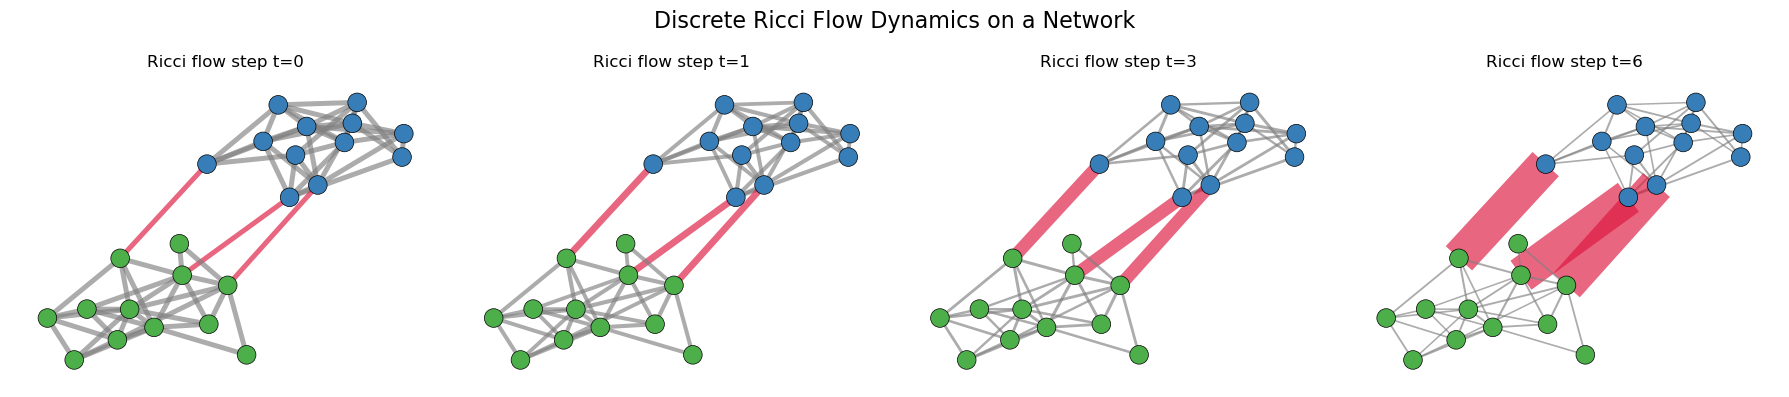

In [10]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

# toy graph: two communities connected by bridges
G = nx.Graph()
left = range(0, 12)
right = range(12, 24)

G.add_nodes_from(left)
G.add_nodes_from(right)

for group in [left, right]:
    for i in group:
        for j in group:
            if i < j and np.random.rand() < 0.45:
                G.add_edge(i, j, weight=1.0)

bridges = [(3, 15), (5, 18), (8, 20)]
G.add_edges_from(bridges, weight=1.0)

pos = nx.spring_layout(G, seed=4)

# fake curvature values for illustration
for u, v in G.edges():
    if (u, v) in bridges or (v, u) in bridges:
        G[u][v]["curvature"] = -0.55
    else:
        G[u][v]["curvature"] = 0.25 + 0.15 * np.random.rand()

eta = 0.8
steps = [0, 1, 3, 6]

graphs = []

for t in range(max(steps) + 1):
    H = G.copy()
    for u, v in H.edges():
        kappa = H[u][v]["curvature"]
        H[u][v]["weight"] = G[u][v]["weight"] * ((1 - eta * kappa) ** t)
    graphs.append(H)

fig, axes = plt.subplots(1, len(steps), figsize=(18, 4))

for ax, t in zip(axes, steps):
    H = graphs[t]
    widths = [0.8 + 2.8 * H[u][v]["weight"] for u, v in H.edges()]
    
    edge_colors = [
        "crimson" if H[u][v]["curvature"] < 0 else "gray"
        for u, v in H.edges()
    ]

    node_colors = ["#377eb8" if n in left else "#4daf4a" for n in H.nodes()]

    nx.draw_networkx_edges(
        H, pos, ax=ax,
        width=widths,
        edge_color=edge_colors,
        alpha=0.65
    )
    nx.draw_networkx_nodes(
        H, pos, ax=ax,
        node_color=node_colors,
        node_size=180,
        edgecolors="black",
        linewidths=0.5
    )

    ax.set_title(f"Ricci flow step t={t}")
    ax.axis("off")

plt.suptitle("Discrete Ricci Flow Dynamics on a Network", fontsize=16)
plt.tight_layout()
plt.show()

fig.savefig("fig4_discrete_ricci_flow_dynamics.png", dpi=400, bbox_inches="tight")
fig.savefig("fig4_discrete_ricci_flow_dynamics.pdf", bbox_inches="tight")

Default configuration:
  LRC pruning = 20%
  ORC pruning = 25%
  alpha       = 0.5
  flow steps  = 3
  eta         = 1.0
  seeds       = [1, 2, 3, 4, 5]

LRC PRUNING SENSITIVITY
Running LRC pruning= 0% | ORC pruning=25% | alpha=0.5
Running LRC pruning= 5% | ORC pruning=25% | alpha=0.5
Running LRC pruning=10% | ORC pruning=25% | alpha=0.5
Running LRC pruning=15% | ORC pruning=25% | alpha=0.5
Running LRC pruning=20% | ORC pruning=25% | alpha=0.5
Running LRC pruning=25% | ORC pruning=25% | alpha=0.5
Running LRC pruning=30% | ORC pruning=25% | alpha=0.5

ORC PRUNING SENSITIVITY
Running LRC pruning=20% | ORC pruning= 5% | alpha=0.5
Running LRC pruning=20% | ORC pruning=10% | alpha=0.5
Running LRC pruning=20% | ORC pruning=15% | alpha=0.5
Running LRC pruning=20% | ORC pruning=20% | alpha=0.5
Running LRC pruning=20% | ORC pruning=25% | alpha=0.5
Running LRC pruning=20% | ORC pruning=30% | alpha=0.5

ALPHA SENSITIVITY
Running LRC pruning=20% | ORC pruning=25% | alpha=0.00
Running LRC pruning=2

,lrc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,0,0.415629,0.021056,0.439467,0.021421,5.155037,0.222925,3412.6,11.480418,14696.6,83.643888,0.0,4906.4
1,5,0.485702,0.013903,0.499697,0.012262,4.831044,0.045850,3443.0,12.389512,13962.6,74.881907,987.2,4659.8
2,10,0.566694,0.018886,0.572841,0.015114,4.649992,0.090996,3457.0,4.582576,13207.6,74.052684,2001.0,4406.6
3,15,0.614315,0.017208,0.618710,0.013063,4.569802,0.069083,3453.2,10.986355,12455.2,84.744911,3003.6,4155.4
4,20,0.513918,0.048987,0.535796,0.037886,4.381211,0.046881,3439.6,8.734987,11741.8,78.254073,3952.6,3918.4
5,25,0.371848,0.044096,0.441759,0.026656,4.204891,0.116996,3410.8,17.796067,10970.0,45.940178,4967.0,3664.8
6,30,0.177236,0.037582,0.335663,0.020139,4.081604,0.068464,3378.2,18.267457,10219.8,36.141389,5948.4,3419.6



ORC-pruning sensitivity summary:


,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,5,0.269464,0.024331,0.304270,0.022016,4.503052,0.036753,3499.2,0.836660,14888.2,100.130914,3952.6,784.2
1,10,0.382622,0.009430,0.406853,0.007738,4.395470,0.082223,3498.0,1.414214,14104.6,94.769721,3952.6,1567.8
2,15,0.463763,0.016191,0.482109,0.013605,4.447175,0.068721,3491.8,1.788854,13320.2,89.499721,3952.6,2351.2
3,20,0.527668,0.018991,0.540378,0.013665,4.369134,0.044516,3477.8,4.207137,12534.6,84.010714,3952.6,3134.8
4,25,0.513918,0.048987,0.535796,0.037886,4.476116,0.108596,3439.6,8.734987,11741.8,78.254073,3952.6,3918.4
5,30,0.458859,0.025261,0.515761,0.017622,4.375966,0.021390,3345.2,20.729206,10922.6,66.281973,3952.6,4702.0



Alpha sensitivity summary:


,alpha,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,0.00,0.057334,0.009274,0.121805,0.004610,4.589141,0.035995,3499.2,0.836660,11754.0,79.082236,3952.6,3918.4
1,0.25,0.268114,0.036905,0.302691,0.029415,4.385733,0.043325,3495.6,1.341641,11753.2,79.335994,3952.6,3918.4
2,0.50,0.513918,0.048987,0.535796,0.037886,4.455448,0.064263,3439.6,8.734987,11741.8,78.254073,3952.6,3918.4
3,0.75,0.448894,0.019936,0.497440,0.015931,4.497217,0.147979,3421.0,15.937377,11746.0,79.511006,3952.6,3918.4


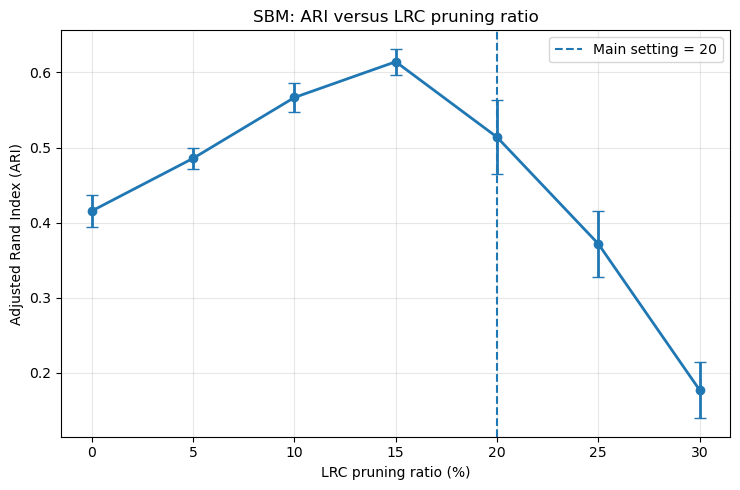

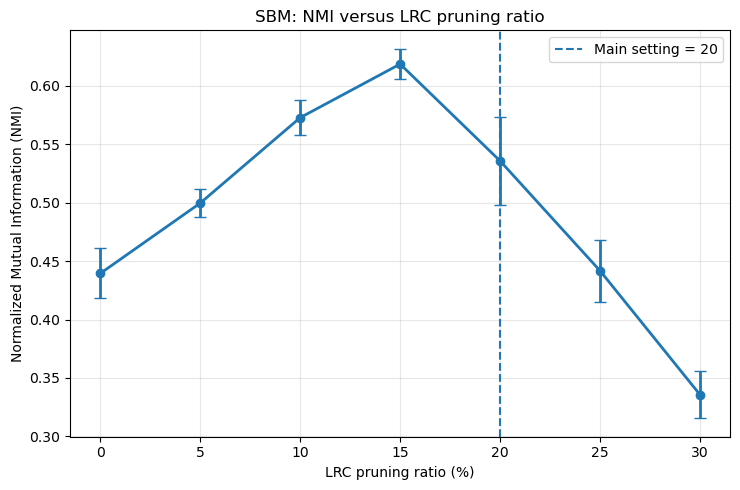

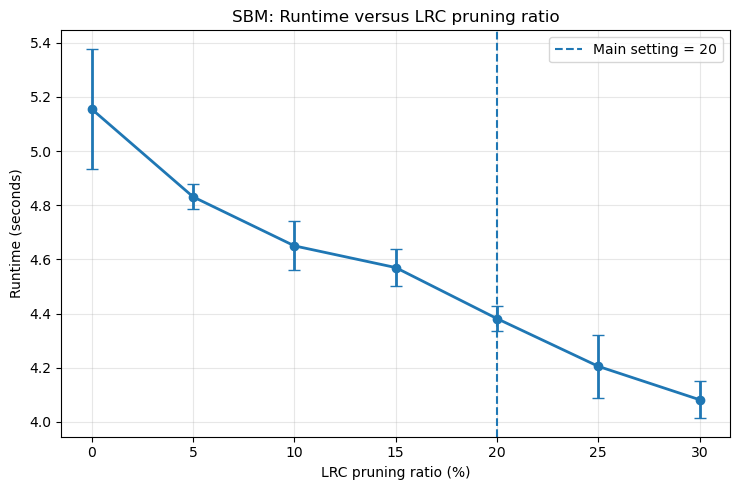

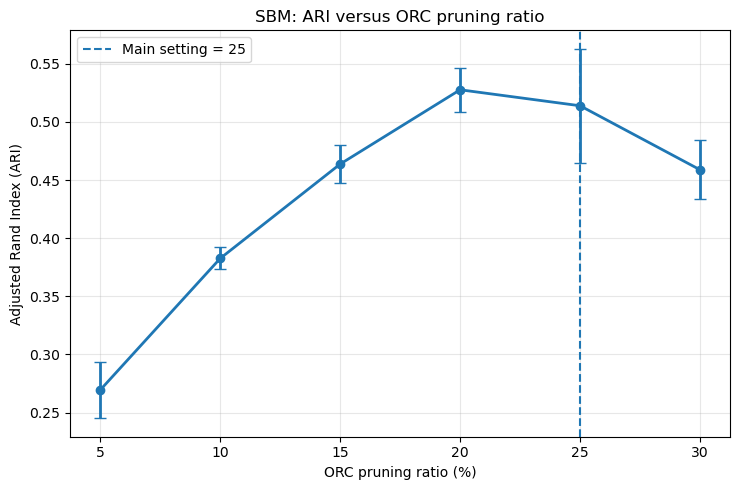

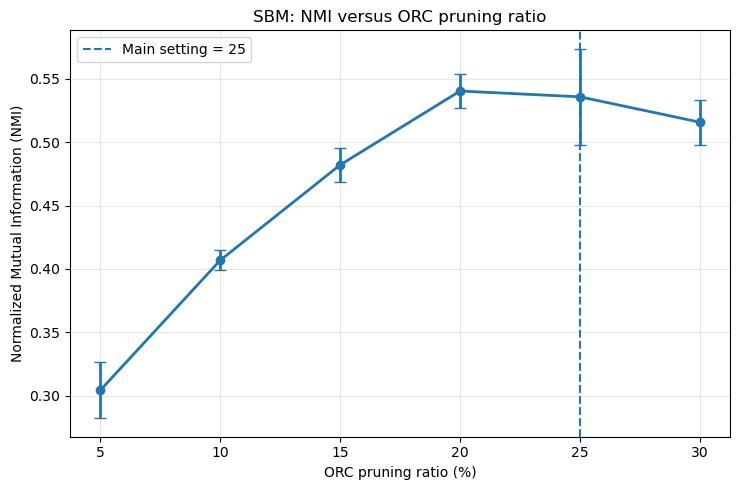

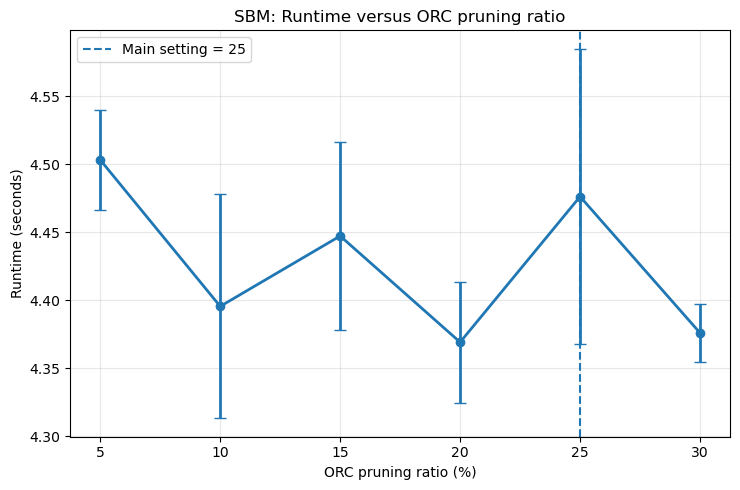

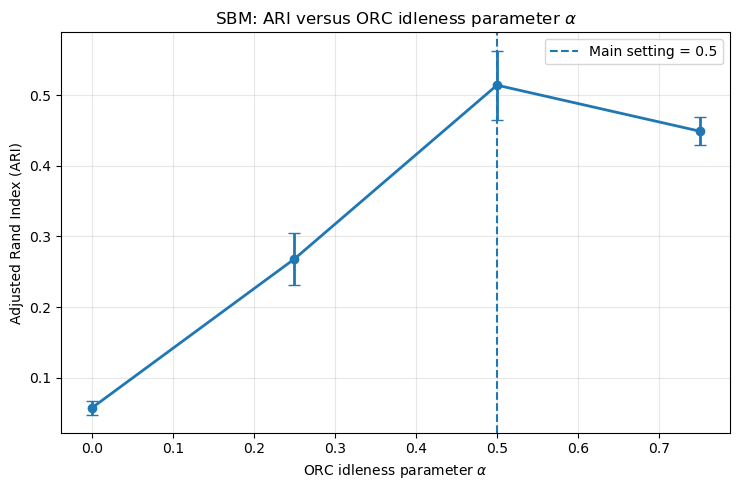

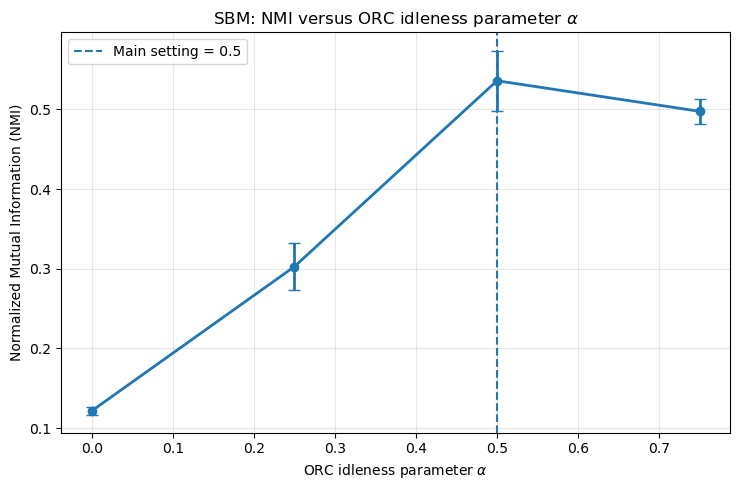

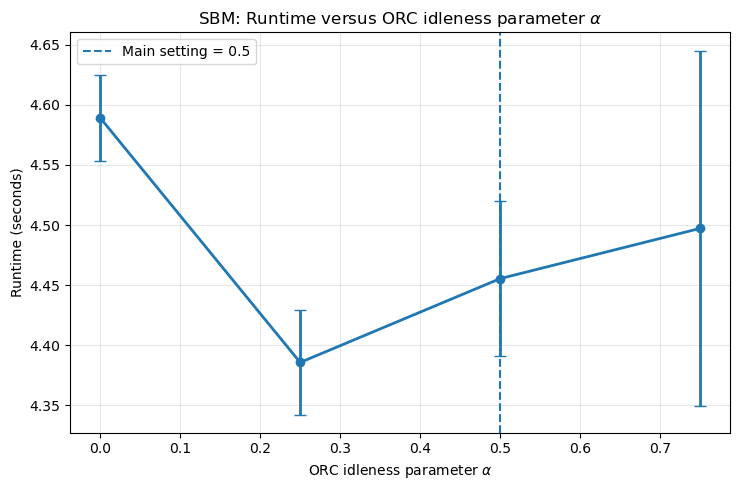


Sensitivity analysis completed successfully.

Generated CSV files:
  sbm_lrc_pruning_sensitivity_raw.csv
  sbm_orc_pruning_sensitivity_raw.csv
  sbm_alpha_sensitivity_raw.csv
  sbm_lrc_pruning_sensitivity_summary.csv
  sbm_orc_pruning_sensitivity_summary.csv
  sbm_alpha_sensitivity_summary.csv

Generated figures:
  sbm_ari_vs_lrc_pruning.png
  sbm_nmi_vs_lrc_pruning.png
  sbm_runtime_vs_lrc_pruning.png
  sbm_ari_vs_orc_pruning.png
  sbm_nmi_vs_orc_pruning.png
  sbm_runtime_vs_orc_pruning.png
  sbm_ari_vs_alpha.png
  sbm_nmi_vs_alpha.png
  sbm_runtime_vs_alpha.png


In [13]:
# ============================================================
# PARAMETER SENSITIVITY ANALYSIS FOR SYNTHETIC SBM
# Combo pipeline: LRC -> ORC
#
# Produces:
#   1. ARI, NMI, Runtime vs LRC pruning
#   2. ARI, NMI, Runtime vs ORC pruning
#   3. ARI, NMI, Runtime vs alpha
#
# Each point is mean +/- standard deviation across independent
# SBM graph realizations.
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. SENSITIVITY SETTINGS
# ============================================================

# Use 5 while developing; change to 10 for final paper results.
SENSITIVITY_SEEDS = [1, 2, 3, 4, 5]

# Values to investigate
LRC_PRUNING_VALUES = [0, 5, 10, 15, 20, 25, 30]
ORC_PRUNING_VALUES = [5, 10, 15, 20, 25, 30]
ALPHA_VALUES = [0.00, 0.25, 0.50, 0.75]

# Current/default configuration used in the main experiment
DEFAULT_LRC_PRUNING = PCT_LRC_COMBO
DEFAULT_ORC_PRUNING = PCT_ORC
DEFAULT_ALPHA = ALPHA_ORC

print("Default configuration:")
print(f"  LRC pruning = {DEFAULT_LRC_PRUNING}%")
print(f"  ORC pruning = {DEFAULT_ORC_PRUNING}%")
print(f"  alpha       = {DEFAULT_ALPHA}")
print(f"  flow steps  = {RICCI_FLOW_STEPS}")
print(f"  eta         = {RICCI_FLOW_ETA}")
print(f"  seeds       = {SENSITIVITY_SEEDS}")


# ============================================================
# 2. RUN ONE PARAMETER-SWEEP CONFIGURATION
# ============================================================

def evaluate_combo_configuration(
    lrc_pct,
    orc_pct,
    alpha,
    seeds,
):
    """
    Evaluate one Combo configuration across independent SBM
    realizations.

    Returns one row per graph realization.
    """

    rows = []

    for seed in seeds:

        # Generate the same type of SBM benchmark used in the
        # main experiment, but with an independent realization.
        G, labels = generate_deceptive_sbm(
            seed,
            **FIXED_PARAMS,
        )

        result = run_combo(
            G=G,
            labels=labels,
            pct_lrc=lrc_pct,
            pct_orc=orc_pct,
            alpha=alpha,
            flow_steps=RICCI_FLOW_STEPS,
            eta=RICCI_FLOW_ETA,
        )

        rows.append(
            {
                "seed": seed,
                "lrc_pct": lrc_pct,
                "orc_pct": orc_pct,
                "alpha": alpha,
                "ARI": result["ARI"],
                "NMI": result["NMI"],
                "Runtime": result["Total_time"],
                "V": result["V"],
                "E": result["E"],
                "removed_lrc": result["removed_lrc"],
                "removed_orc": result["removed_orc"],
            }
        )

    return rows


# ============================================================
# 3. LRC-PRUNING SENSITIVITY
#
# Vary LRC pruning while holding:
#   ORC pruning = default
#   alpha       = default
# ============================================================

lrc_sweep_rows = []

print("\n" + "=" * 70)
print("LRC PRUNING SENSITIVITY")
print("=" * 70)

for lrc_pct in LRC_PRUNING_VALUES:

    print(
        f"Running LRC pruning={lrc_pct:>2}% | "
        f"ORC pruning={DEFAULT_ORC_PRUNING}% | "
        f"alpha={DEFAULT_ALPHA}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=lrc_pct,
        orc_pct=DEFAULT_ORC_PRUNING,
        alpha=DEFAULT_ALPHA,
        seeds=SENSITIVITY_SEEDS,
    )

    lrc_sweep_rows.extend(rows)


df_lrc_sensitivity = pd.DataFrame(
    lrc_sweep_rows
)


# ============================================================
# 4. ORC-PRUNING SENSITIVITY
#
# Vary ORC pruning while holding:
#   LRC pruning = default
#   alpha       = default
# ============================================================

orc_sweep_rows = []

print("\n" + "=" * 70)
print("ORC PRUNING SENSITIVITY")
print("=" * 70)

for orc_pct in ORC_PRUNING_VALUES:

    print(
        f"Running LRC pruning={DEFAULT_LRC_PRUNING}% | "
        f"ORC pruning={orc_pct:>2}% | "
        f"alpha={DEFAULT_ALPHA}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=DEFAULT_LRC_PRUNING,
        orc_pct=orc_pct,
        alpha=DEFAULT_ALPHA,
        seeds=SENSITIVITY_SEEDS,
    )

    orc_sweep_rows.extend(rows)


df_orc_sensitivity = pd.DataFrame(
    orc_sweep_rows
)


# ============================================================
# 5. ALPHA SENSITIVITY
#
# Vary alpha while holding both pruning values fixed.
# ============================================================

alpha_sweep_rows = []

print("\n" + "=" * 70)
print("ALPHA SENSITIVITY")
print("=" * 70)

for alpha in ALPHA_VALUES:

    print(
        f"Running LRC pruning={DEFAULT_LRC_PRUNING}% | "
        f"ORC pruning={DEFAULT_ORC_PRUNING}% | "
        f"alpha={alpha:.2f}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=DEFAULT_LRC_PRUNING,
        orc_pct=DEFAULT_ORC_PRUNING,
        alpha=alpha,
        seeds=SENSITIVITY_SEEDS,
    )

    alpha_sweep_rows.extend(rows)


df_alpha_sensitivity = pd.DataFrame(
    alpha_sweep_rows
)


# ============================================================
# 6. SUMMARIZE MEAN +/- STANDARD DEVIATION
# ============================================================

def summarize_sensitivity(
    dataframe,
    parameter_column,
):
    """
    Summarize ARI, NMI, runtime, and graph size for one
    parameter sweep.
    """

    summary = (
        dataframe
        .groupby(
            parameter_column,
            as_index=False,
        )
        .agg(
            ARI_mean=("ARI", "mean"),
            ARI_std=("ARI", "std"),
            NMI_mean=("NMI", "mean"),
            NMI_std=("NMI", "std"),
            Runtime_mean=("Runtime", "mean"),
            Runtime_std=("Runtime", "std"),
            V_mean=("V", "mean"),
            V_std=("V", "std"),
            E_mean=("E", "mean"),
            E_std=("E", "std"),
            Removed_LRC_mean=("removed_lrc", "mean"),
            Removed_ORC_mean=("removed_orc", "mean"),
        )
        .sort_values(parameter_column)
        .reset_index(drop=True)
    )

    return summary


lrc_sensitivity_summary = summarize_sensitivity(
    df_lrc_sensitivity,
    parameter_column="lrc_pct",
)

orc_sensitivity_summary = summarize_sensitivity(
    df_orc_sensitivity,
    parameter_column="orc_pct",
)

alpha_sensitivity_summary = summarize_sensitivity(
    df_alpha_sensitivity,
    parameter_column="alpha",
)


print("\nLRC-pruning sensitivity summary:")
display(lrc_sensitivity_summary)

print("\nORC-pruning sensitivity summary:")
display(orc_sensitivity_summary)

print("\nAlpha sensitivity summary:")
display(alpha_sensitivity_summary)


# ============================================================
# 7. SAVE RAW AND SUMMARY RESULTS
# ============================================================

df_lrc_sensitivity.to_csv(
    "sbm_lrc_pruning_sensitivity_raw.csv",
    index=False,
)

df_orc_sensitivity.to_csv(
    "sbm_orc_pruning_sensitivity_raw.csv",
    index=False,
)

df_alpha_sensitivity.to_csv(
    "sbm_alpha_sensitivity_raw.csv",
    index=False,
)

lrc_sensitivity_summary.to_csv(
    "sbm_lrc_pruning_sensitivity_summary.csv",
    index=False,
)

orc_sensitivity_summary.to_csv(
    "sbm_orc_pruning_sensitivity_summary.csv",
    index=False,
)

alpha_sensitivity_summary.to_csv(
    "sbm_alpha_sensitivity_summary.csv",
    index=False,
)


# ============================================================
# 8. PLOTTING HELPER
# ============================================================

def plot_sensitivity_metric(
    summary,
    x_column,
    mean_column,
    std_column,
    x_label,
    y_label,
    title,
    default_value,
    output_filename,
):
    """
    Create one publication-style mean +/- std sensitivity plot.
    """

    fig, ax = plt.subplots(
        figsize=(7.5, 5.0)
    )

    ax.errorbar(
        summary[x_column],
        summary[mean_column],
        yerr=summary[std_column],
        marker="o",
        linewidth=2,
        capsize=4,
    )

    # Mark the parameter value used in the main experiment
    ax.axvline(
        default_value,
        linestyle="--",
        linewidth=1.5,
        label=f"Main setting = {default_value}",
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(
        True,
        alpha=0.3,
    )
    ax.legend()
    fig.tight_layout()

    fig.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 9. LRC-PRUNING PLOTS
# ============================================================

plot_sensitivity_metric(
    summary=lrc_sensitivity_summary,
    x_column="lrc_pct",
    mean_column="ARI_mean",
    std_column="ARI_std",
    x_label="LRC pruning ratio (%)",
    y_label="Adjusted Rand Index (ARI)",
    title="SBM: ARI versus LRC pruning ratio",
    default_value=DEFAULT_LRC_PRUNING,
    output_filename="sbm_ari_vs_lrc_pruning.png",
)

plot_sensitivity_metric(
    summary=lrc_sensitivity_summary,
    x_column="lrc_pct",
    mean_column="NMI_mean",
    std_column="NMI_std",
    x_label="LRC pruning ratio (%)",
    y_label="Normalized Mutual Information (NMI)",
    title="SBM: NMI versus LRC pruning ratio",
    default_value=DEFAULT_LRC_PRUNING,
    output_filename="sbm_nmi_vs_lrc_pruning.png",
)

plot_sensitivity_metric(
    summary=lrc_sensitivity_summary,
    x_column="lrc_pct",
    mean_column="Runtime_mean",
    std_column="Runtime_std",
    x_label="LRC pruning ratio (%)",
    y_label="Runtime (seconds)",
    title="SBM: Runtime versus LRC pruning ratio",
    default_value=DEFAULT_LRC_PRUNING,
    output_filename="sbm_runtime_vs_lrc_pruning.png",
)


# ============================================================
# 10. ORC-PRUNING PLOTS
# ============================================================

plot_sensitivity_metric(
    summary=orc_sensitivity_summary,
    x_column="orc_pct",
    mean_column="ARI_mean",
    std_column="ARI_std",
    x_label="ORC pruning ratio (%)",
    y_label="Adjusted Rand Index (ARI)",
    title="SBM: ARI versus ORC pruning ratio",
    default_value=DEFAULT_ORC_PRUNING,
    output_filename="sbm_ari_vs_orc_pruning.png",
)

plot_sensitivity_metric(
    summary=orc_sensitivity_summary,
    x_column="orc_pct",
    mean_column="NMI_mean",
    std_column="NMI_std",
    x_label="ORC pruning ratio (%)",
    y_label="Normalized Mutual Information (NMI)",
    title="SBM: NMI versus ORC pruning ratio",
    default_value=DEFAULT_ORC_PRUNING,
    output_filename="sbm_nmi_vs_orc_pruning.png",
)

plot_sensitivity_metric(
    summary=orc_sensitivity_summary,
    x_column="orc_pct",
    mean_column="Runtime_mean",
    std_column="Runtime_std",
    x_label="ORC pruning ratio (%)",
    y_label="Runtime (seconds)",
    title="SBM: Runtime versus ORC pruning ratio",
    default_value=DEFAULT_ORC_PRUNING,
    output_filename="sbm_runtime_vs_orc_pruning.png",
)


# ============================================================
# 11. ALPHA PLOTS
# ============================================================

plot_sensitivity_metric(
    summary=alpha_sensitivity_summary,
    x_column="alpha",
    mean_column="ARI_mean",
    std_column="ARI_std",
    x_label=r"ORC idleness parameter $\alpha$",
    y_label="Adjusted Rand Index (ARI)",
    title=r"SBM: ARI versus ORC idleness parameter $\alpha$",
    default_value=DEFAULT_ALPHA,
    output_filename="sbm_ari_vs_alpha.png",
)

plot_sensitivity_metric(
    summary=alpha_sensitivity_summary,
    x_column="alpha",
    mean_column="NMI_mean",
    std_column="NMI_std",
    x_label=r"ORC idleness parameter $\alpha$",
    y_label="Normalized Mutual Information (NMI)",
    title=r"SBM: NMI versus ORC idleness parameter $\alpha$",
    default_value=DEFAULT_ALPHA,
    output_filename="sbm_nmi_vs_alpha.png",
)

plot_sensitivity_metric(
    summary=alpha_sensitivity_summary,
    x_column="alpha",
    mean_column="Runtime_mean",
    std_column="Runtime_std",
    x_label=r"ORC idleness parameter $\alpha$",
    y_label="Runtime (seconds)",
    title=r"SBM: Runtime versus ORC idleness parameter $\alpha$",
    default_value=DEFAULT_ALPHA,
    output_filename="sbm_runtime_vs_alpha.png",
)


# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\nSensitivity analysis completed successfully.")

print("\nGenerated CSV files:")
print("  sbm_lrc_pruning_sensitivity_raw.csv")
print("  sbm_orc_pruning_sensitivity_raw.csv")
print("  sbm_alpha_sensitivity_raw.csv")
print("  sbm_lrc_pruning_sensitivity_summary.csv")
print("  sbm_orc_pruning_sensitivity_summary.csv")
print("  sbm_alpha_sensitivity_summary.csv")

print("\nGenerated figures:")
print("  sbm_ari_vs_lrc_pruning.png")
print("  sbm_nmi_vs_lrc_pruning.png")
print("  sbm_runtime_vs_lrc_pruning.png")
print("  sbm_ari_vs_orc_pruning.png")
print("  sbm_nmi_vs_orc_pruning.png")
print("  sbm_runtime_vs_orc_pruning.png")
print("  sbm_ari_vs_alpha.png")
print("  sbm_nmi_vs_alpha.png")
print("  sbm_runtime_vs_alpha.png")

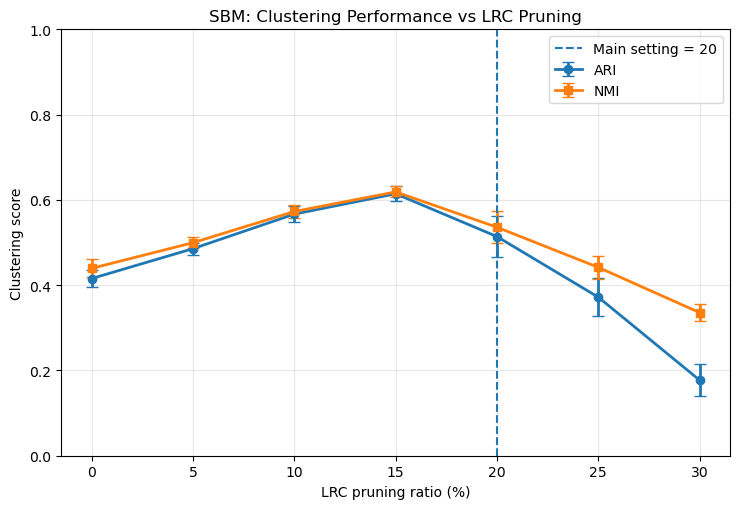

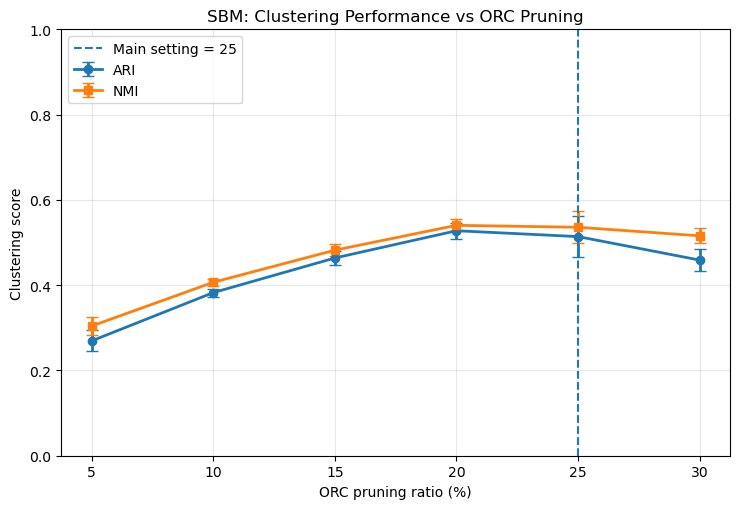

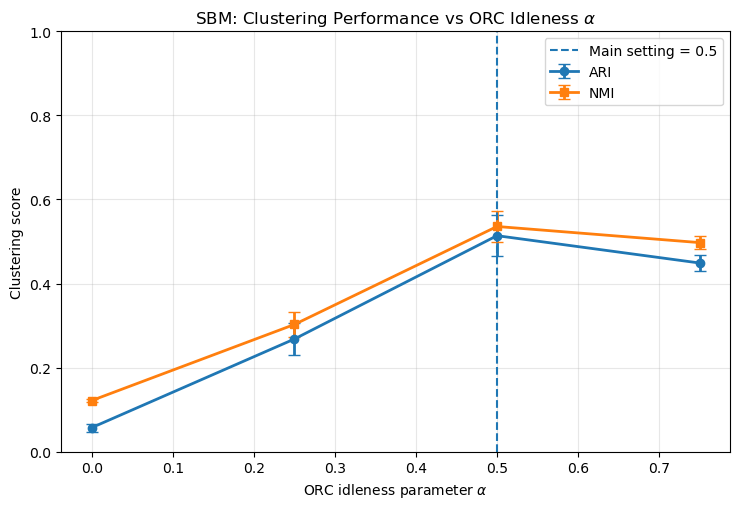


3 x 3 LRC × ORC HEATMAP ANALYSIS
LRC values: [10, 20, 30]
ORC values: [15, 25, 35]
Fixed alpha: 0.5
Seeds: [1, 2, 3, 4, 5]

Running LRC=10% | ORC=15% | alpha=0.5

Running LRC=10% | ORC=25% | alpha=0.5

Running LRC=10% | ORC=35% | alpha=0.5

Running LRC=20% | ORC=15% | alpha=0.5

Running LRC=20% | ORC=25% | alpha=0.5

Running LRC=20% | ORC=35% | alpha=0.5

Running LRC=30% | ORC=15% | alpha=0.5

Running LRC=30% | ORC=25% | alpha=0.5

Running LRC=30% | ORC=35% | alpha=0.5

3x3 heatmap summary:


,lrc_pct,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std
0,10,15,0.494987,0.017152,0.506858,0.014038,4.775005,0.171848
1,10,25,0.566694,0.018886,0.572841,0.015114,5.182767,0.864910
2,10,35,0.479816,0.028344,0.511918,0.023756,5.021510,0.395476
3,20,15,0.463763,0.016191,0.482109,0.013605,4.451248,0.161889
4,20,25,0.513918,0.048987,0.535796,0.037886,4.437445,0.144041
5,20,35,0.326866,0.028779,0.473858,0.014020,4.405863,0.256330
6,30,15,0.271033,0.031643,0.334133,0.022188,4.382171,0.173456
7,30,25,0.177236,0.037582,0.335663,0.020139,4.149102,0.179253
8,30,35,0.108236,0.012622,0.337541,0.020840,4.117140,0.152924


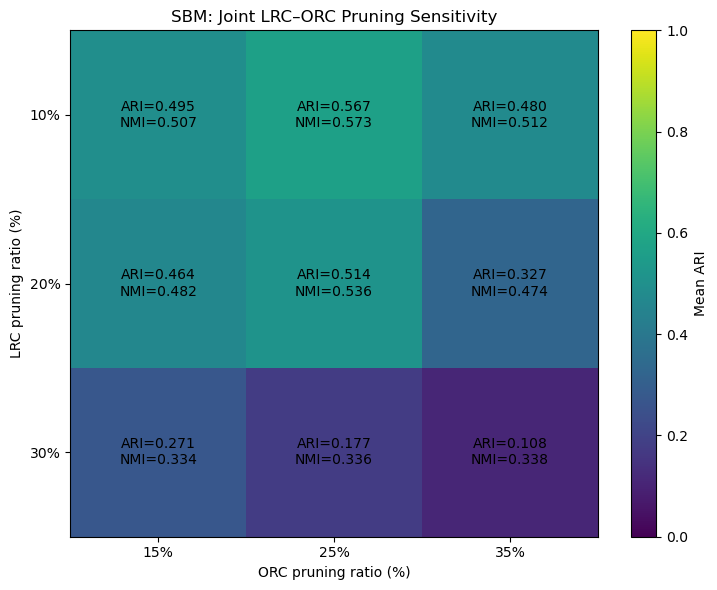

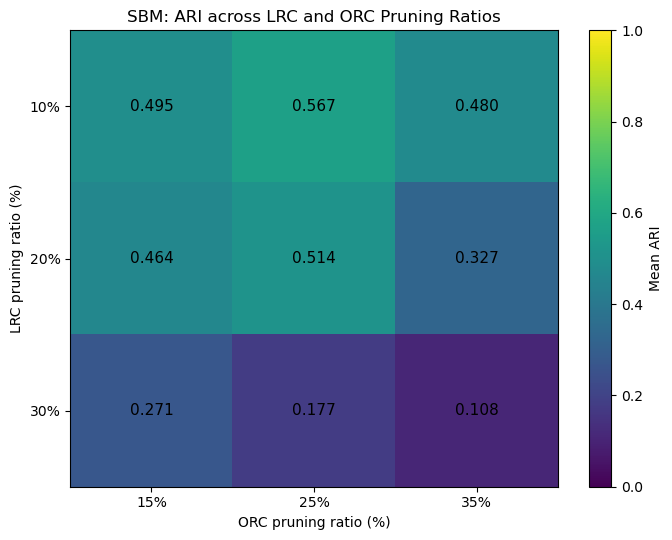

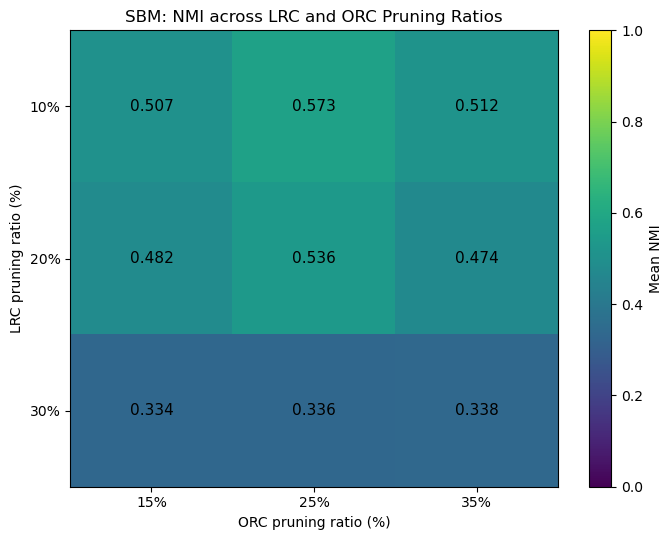


FINAL FIGURES CREATED

Main figures:
1. sbm_ari_nmi_vs_lrc_pruning.png
2. sbm_ari_nmi_vs_orc_pruning.png
3. sbm_ari_nmi_vs_alpha.png
4. sbm_lrc_orc_combined_heatmap.png

Additional heatmaps:
5. sbm_ari_lrc_orc_heatmap.png
6. sbm_nmi_lrc_orc_heatmap.png


In [14]:
# ============================================================
# FINAL PARAMETER-SENSITIVITY FIGURES FOR THE PAPER
#
# Produces:
#   Figure 1: ARI + NMI vs LRC pruning
#   Figure 2: ARI + NMI vs ORC pruning
#   Figure 3: ARI + NMI vs alpha
#   Figure 4: 3x3 LRC x ORC heatmap with ARI and NMI
#
# Run this AFTER the previous sensitivity-analysis cell.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. HELPER FUNCTION:
#    ARI AND NMI ON THE SAME PLOT
# ============================================================

def plot_ari_nmi_together(
    summary,
    x_col,
    x_label,
    title,
    default_value,
    output_filename,
):
    """
    Plot mean ARI and NMI together with standard-deviation error bars.
    """

    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # ARI
    ax.errorbar(
        summary[x_col],
        summary["ARI_mean"],
        yerr=summary["ARI_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="ARI",
    )

    # NMI
    ax.errorbar(
        summary[x_col],
        summary["NMI_mean"],
        yerr=summary["NMI_std"],
        marker="s",
        linewidth=2,
        capsize=4,
        label="NMI",
    )

    # Main parameter value used in the experiment
    ax.axvline(
        default_value,
        linestyle="--",
        linewidth=1.5,
        label=f"Main setting = {default_value}",
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Clustering score")
    ax.set_title(title)

    ax.set_ylim(0, 1)

    ax.grid(
        True,
        alpha=0.3,
    )

    ax.legend()

    fig.tight_layout()

    fig.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


# ============================================================
# 2. FIGURE 1:
#    ARI + NMI vs LRC PRUNING
# ============================================================

plot_ari_nmi_together(
    summary=lrc_sensitivity_summary,
    x_col="lrc_pct",
    x_label="LRC pruning ratio (%)",
    title="SBM: Clustering Performance vs LRC Pruning",
    default_value=DEFAULT_LRC_PRUNING,
    output_filename="sbm_ari_nmi_vs_lrc_pruning.png",
)


# ============================================================
# 3. FIGURE 2:
#    ARI + NMI vs ORC PRUNING
# ============================================================

plot_ari_nmi_together(
    summary=orc_sensitivity_summary,
    x_col="orc_pct",
    x_label="ORC pruning ratio (%)",
    title="SBM: Clustering Performance vs ORC Pruning",
    default_value=DEFAULT_ORC_PRUNING,
    output_filename="sbm_ari_nmi_vs_orc_pruning.png",
)


# ============================================================
# 4. FIGURE 3:
#    ARI + NMI vs ALPHA
# ============================================================

plot_ari_nmi_together(
    summary=alpha_sensitivity_summary,
    x_col="alpha",
    x_label=r"ORC idleness parameter $\alpha$",
    title=r"SBM: Clustering Performance vs ORC Idleness $\alpha$",
    default_value=DEFAULT_ALPHA,
    output_filename="sbm_ari_nmi_vs_alpha.png",
)


# ============================================================
# 5. HEATMAP SETTINGS
#
# 3 LRC values x 3 ORC values = 9 configurations
#
# These values surround the main parameter region.
# Change them later if Sarah wants a different range.
# ============================================================

LRC_HEAT_VALUES = [
    10,
    20,
    30,
]

ORC_HEAT_VALUES = [
    15,
    25,
    35,
]


print("\n" + "=" * 70)
print("3 x 3 LRC × ORC HEATMAP ANALYSIS")
print("=" * 70)

print("LRC values:", LRC_HEAT_VALUES)
print("ORC values:", ORC_HEAT_VALUES)
print("Fixed alpha:", DEFAULT_ALPHA)
print("Seeds:", SENSITIVITY_SEEDS)


# ============================================================
# 6. RUN THE 3 x 3 GRID
# ============================================================

heatmap_rows = []

for lrc_pct in LRC_HEAT_VALUES:

    for orc_pct in ORC_HEAT_VALUES:

        print(
            f"\nRunning "
            f"LRC={lrc_pct}% | "
            f"ORC={orc_pct}% | "
            f"alpha={DEFAULT_ALPHA}"
        )

        rows = evaluate_combo_configuration(
            lrc_pct=lrc_pct,
            orc_pct=orc_pct,
            alpha=DEFAULT_ALPHA,
            seeds=SENSITIVITY_SEEDS,
        )

        heatmap_rows.extend(rows)


df_heatmap_raw = pd.DataFrame(
    heatmap_rows
)


# ============================================================
# 7. AVERAGE ACROSS SEEDS
# ============================================================

heatmap_summary = (
    df_heatmap_raw
    .groupby(
        [
            "lrc_pct",
            "orc_pct",
        ],
        as_index=False,
    )
    .agg(
        ARI_mean=("ARI", "mean"),
        ARI_std=("ARI", "std"),

        NMI_mean=("NMI", "mean"),
        NMI_std=("NMI", "std"),

        Runtime_mean=("Runtime", "mean"),
        Runtime_std=("Runtime", "std"),
    )
)


print("\n3x3 heatmap summary:")
display(heatmap_summary)


# Save results
df_heatmap_raw.to_csv(
    "sbm_lrc_orc_heatmap_raw.csv",
    index=False,
)

heatmap_summary.to_csv(
    "sbm_lrc_orc_heatmap_summary.csv",
    index=False,
)


# ============================================================
# 8. CREATE ARI AND NMI MATRICES
# ============================================================

ari_matrix = (
    heatmap_summary
    .pivot(
        index="lrc_pct",
        columns="orc_pct",
        values="ARI_mean",
    )
    .reindex(
        index=LRC_HEAT_VALUES,
        columns=ORC_HEAT_VALUES,
    )
)


nmi_matrix = (
    heatmap_summary
    .pivot(
        index="lrc_pct",
        columns="orc_pct",
        values="NMI_mean",
    )
    .reindex(
        index=LRC_HEAT_VALUES,
        columns=ORC_HEAT_VALUES,
    )
)


# ============================================================
# 9. COMBINED HEATMAP
#
# Cell annotation:
# ARI = ...
# NMI = ...
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.5, 6.0)
)

# Use ARI as heat intensity
image = ax.imshow(
    ari_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

ax.set_xticks(
    np.arange(
        len(ORC_HEAT_VALUES)
    )
)

ax.set_xticklabels(
    [
        f"{value}%"
        for value in ORC_HEAT_VALUES
    ]
)


ax.set_yticks(
    np.arange(
        len(LRC_HEAT_VALUES)
    )
)

ax.set_yticklabels(
    [
        f"{value}%"
        for value in LRC_HEAT_VALUES
    ]
)


ax.set_xlabel(
    "ORC pruning ratio (%)"
)

ax.set_ylabel(
    "LRC pruning ratio (%)"
)

ax.set_title(
    "SBM: Joint LRC–ORC Pruning Sensitivity"
)


# ============================================================
# 10. WRITE ARI AND NMI INSIDE EACH CELL
# ============================================================

for i, lrc_pct in enumerate(
    LRC_HEAT_VALUES
):

    for j, orc_pct in enumerate(
        ORC_HEAT_VALUES
    ):

        ari_value = (
            ari_matrix
            .loc[
                lrc_pct,
                orc_pct
            ]
        )

        nmi_value = (
            nmi_matrix
            .loc[
                lrc_pct,
                orc_pct
            ]
        )

        ax.text(
            j,
            i,
            (
                f"ARI={ari_value:.3f}\n"
                f"NMI={nmi_value:.3f}"
            ),
            ha="center",
            va="center",
            fontsize=10,
        )


# ============================================================
# 11. COLOR BAR
# ============================================================

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Mean ARI"
)


fig.tight_layout()

fig.savefig(
    "sbm_lrc_orc_combined_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 12. OPTIONAL:
#     SEPARATE ARI HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5.5)
)

image = ax.imshow(
    ari_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    np.arange(
        len(ORC_HEAT_VALUES)
    )
)

ax.set_xticklabels(
    [
        f"{value}%"
        for value in ORC_HEAT_VALUES
    ]
)

ax.set_yticks(
    np.arange(
        len(LRC_HEAT_VALUES)
    )
)

ax.set_yticklabels(
    [
        f"{value}%"
        for value in LRC_HEAT_VALUES
    ]
)

for i in range(
    len(LRC_HEAT_VALUES)
):

    for j in range(
        len(ORC_HEAT_VALUES)
    ):

        ax.text(
            j,
            i,
            f"{ari_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=11,
        )

ax.set_xlabel(
    "ORC pruning ratio (%)"
)

ax.set_ylabel(
    "LRC pruning ratio (%)"
)

ax.set_title(
    "SBM: ARI across LRC and ORC Pruning Ratios"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Mean ARI"
)

fig.tight_layout()

fig.savefig(
    "sbm_ari_lrc_orc_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 13. OPTIONAL:
#     SEPARATE NMI HEATMAP
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 5.5)
)

image = ax.imshow(
    nmi_matrix.values,
    aspect="auto",
    vmin=0,
    vmax=1,
)

ax.set_xticks(
    np.arange(
        len(ORC_HEAT_VALUES)
    )
)

ax.set_xticklabels(
    [
        f"{value}%"
        for value in ORC_HEAT_VALUES
    ]
)

ax.set_yticks(
    np.arange(
        len(LRC_HEAT_VALUES)
    )
)

ax.set_yticklabels(
    [
        f"{value}%"
        for value in LRC_HEAT_VALUES
    ]
)

for i in range(
    len(LRC_HEAT_VALUES)
):

    for j in range(
        len(ORC_HEAT_VALUES)
    ):

        ax.text(
            j,
            i,
            f"{nmi_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center",
            fontsize=11,
        )

ax.set_xlabel(
    "ORC pruning ratio (%)"
)

ax.set_ylabel(
    "LRC pruning ratio (%)"
)

ax.set_title(
    "SBM: NMI across LRC and ORC Pruning Ratios"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Mean NMI"
)

fig.tight_layout()

fig.savefig(
    "sbm_nmi_lrc_orc_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


# ============================================================
# 14. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)
print("FINAL FIGURES CREATED")
print("=" * 70)

print(
    "\nMain figures:"
)

print(
    "1. sbm_ari_nmi_vs_lrc_pruning.png"
)

print(
    "2. sbm_ari_nmi_vs_orc_pruning.png"
)

print(
    "3. sbm_ari_nmi_vs_alpha.png"
)

print(
    "4. sbm_lrc_orc_combined_heatmap.png"
)

print(
    "\nAdditional heatmaps:"
)

print(
    "5. sbm_ari_lrc_orc_heatmap.png"
)

print(
    "6. sbm_nmi_lrc_orc_heatmap.png"
)